# Georgia Market Risk Analytics


## Project setup
Imports and constants used across the research notebook.


In [288]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                            accuracy_score, balanced_accuracy_score, brier_score_loss, confusion_matrix, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier

## Load cleaned datasets
Loads cleaned market files and aligns them before returns and factor work.


In [290]:
START = "2018-01-01"
END = "2026-05-08"

DATA_DIR = Path(r"Data\Processed")

paths = {
    "FX": DATA_DIR / "FX.csv",
    "currencies": DATA_DIR / "currencies.csv",
    "TIBR": DATA_DIR / "TIBR.csv",
    "cryptos": DATA_DIR / "cryptos.csv",
    "commodities": DATA_DIR / "commodities.csv",
    "yields": DATA_DIR / "yields.csv",
    "all_market": DATA_DIR / "all_market.csv",
    "bond_prices_filled": DATA_DIR / "bond_prices_filled.csv",
    "bond_yields_pct": DATA_DIR / "bond_yields_pct.csv",
    "ice_tri_levels": DATA_DIR / "ice_tri_levels.csv",
    "ice_price_levels": DATA_DIR / "ice_price_levels.csv",
    "market_volumes": DATA_DIR / "market_volumes.csv"
    
}

BOND_META_PATH = "Data/bond_metadata.csv"

In [291]:
def clean_market_csv(path):
    """
    Loads one market CSV, detects date column, cleans numeric columns,
    removes duplicate dates, and returns Date-indexed dataframe.
    """
    df = pd.read_csv(path)
    df.columns = df.columns.astype(str).str.strip()

    possible_date_cols = ["Date", "date", "DATE", "Datetime", "datetime"]

    date_col = None
    for col in possible_date_cols:
        if col in df.columns:
            date_col = col
            break

    # If no explicit date column exists, assume first column is the date/index
    if date_col is None:
        date_col = df.columns[0]

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.rename(columns={date_col: "Date"})
    df = df.dropna(subset=["Date"])
    df = df.set_index("Date").sort_index()

    # Remove useless unnamed columns after date has been set
    df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", case=False, regex=True)]

    # Remove duplicate dates
    df = df[~df.index.duplicated(keep="last")]

    # Convert all columns to numeric
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("%", "", regex=False)
                .str.strip()
                .replace({"": np.nan, "nan": np.nan, "None": np.nan, "-": np.nan})
            )

        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.loc[START:END]

    return df


raw = {name: clean_market_csv(path) for name, path in paths.items()}

In [292]:
raw['ice_tri_levels'] = raw['ice_tri_levels'].drop(columns=['GDGE'])

In [293]:
raw_summary = []

for name, df in raw.items():
    raw_summary.append({
        "dataset": name,
        "start": df.index.min(),
        "end": df.index.max(),
        "rows": df.shape[0],
        "cols": df.shape[1],
        "missing": int(df.isna().sum().sum())
    })

raw_summary = pd.DataFrame(raw_summary)
raw_summary

,dataset,start,end,rows,cols,missing
0,FX,2018-01-01,2026-05-08,2174,7,0
1,currencies,2018-01-01,2026-05-08,2174,10,0
2,TIBR,2018-01-03,2026-05-07,2081,4,888
3,cryptos,2018-01-01,2026-05-08,3050,2,0
4,commodities,2018-01-02,2026-05-08,2102,3,3
5,yields,2018-01-02,2026-05-08,2099,3,0
6,all_market,2018-01-01,2026-05-08,2174,12,117
7,bond_prices_filled,2018-01-01,2026-05-08,2186,16,11912
8,bond_yields_pct,2018-01-01,2026-05-08,2186,16,11912
9,ice_tri_levels,2018-01-02,2026-05-08,2185,11,15733


In [294]:
bond_meta = pd.read_csv(BOND_META_PATH)

bond_meta.columns = bond_meta.columns.str.strip().str.lower()

bond_meta["maturity_date"] = pd.to_datetime(
    bond_meta["maturity_date"],
    errors="coerce"
)

bond_meta["issuer"] = bond_meta["issuer"].astype(str).str.strip()

local_bond_issuers = ["Georgia", "TBC_Bank", "Bank_of_Georgia"]
regional_bond_issuers = ["Turkey", "Russia", "Armenia", "Azerbaijan"]

bond_meta["bond_region"] = np.select(
    [
        bond_meta["issuer"].isin(local_bond_issuers),
        bond_meta["issuer"].isin(regional_bond_issuers),
    ],
    [
        "local_georgia",
        "regional",
    ],
    default="other"
)

bond_meta["maturity_year"] = bond_meta["maturity_date"].dt.year

bond_meta[["isin", "issuer", "bond_region", "coupon", "maturity_date", "maturity_year"]]

,isin,issuer,bond_region,coupon,maturity_date,maturity_year
0,US900123BB58,Turkey,regional,7.250,2038-03-05,2038
1,US900123AY60,Turkey,regional,6.875,2036-03-17,2036
2,US900123CB40,Turkey,regional,4.875,2043-04-16,2043
3,RU000A0JXU14,Russia,regional,5.250,2047-06-23,2047
4,XS0767473852,Russia,regional,5.625,2042-04-04,2042
5,XS0088543193,Russia,regional,12.750,2028-06-24,2028
6,RU000A1006S9,Russia,regional,5.100,2035-03-28,2035
7,XS3020792696,Armenia,regional,6.750,2035-03-12,2035
8,XS2010028939,Armenia,regional,3.600,2031-02-02,2031
9,XS2010043904,Armenia,regional,3.950,2029-09-26,2029


In [295]:
def make_bond_name_map(bond_meta):
    """
    Creates readable names for ISIN columns.
    Example:
    XS2334109423 -> Georgia__XS2334109423__mat2026
    """
    name_map = {}

    for _, row in bond_meta.iterrows():
        isin = row["isin"]
        issuer = row["issuer"]
        mat_year = row["maturity_year"]

        name_map[isin] = f"{issuer}__{isin}__mat{mat_year}"

    return name_map


bond_name_map = make_bond_name_map(bond_meta)
bond_name_map

{'US900123BB58': 'Turkey__US900123BB58__mat2038',
 'US900123AY60': 'Turkey__US900123AY60__mat2036',
 'US900123CB40': 'Turkey__US900123CB40__mat2043',
 'RU000A0JXU14': 'Russia__RU000A0JXU14__mat2047',
 'XS0767473852': 'Russia__XS0767473852__mat2042',
 'XS0088543193': 'Russia__XS0088543193__mat2028',
 'RU000A1006S9': 'Russia__RU000A1006S9__mat2035',
 'XS3020792696': 'Armenia__XS3020792696__mat2035',
 'XS2010028939': 'Armenia__XS2010028939__mat2031',
 'XS2010043904': 'Armenia__XS2010043904__mat2029',
 'XS1678623734': 'Azerbaijan__XS1678623734__mat2032',
 'XS1678623064': 'Azerbaijan__XS1678623064__mat2029',
 'XS2808539410': 'TBC_Bank__XS2808539410__mat2029',
 'XS2334109423': 'Georgia__XS2334109423__mat2026',
 'XS3262542155': 'Georgia__XS3262542155__mat2031',
 'XS2801343414': 'Bank_of_Georgia__XS2801343414__mat2029'}

In [296]:
master_index = raw["FX"].index

ffill_limits = {
    "FX": None,
    "currencies": None,
    "TIBR": 5,
    "cryptos": 3,
    "commodities": 5,
    "yields": 5,
    "all_market": None,
    "bond_prices_filled": None,
    "bond_yields_pct": None,
    "ice_tri_levels": None,
    "ice_price_levels": None,
    "market_volumes": None,
}


def align_to_master(df, master_index, ffill_limit=None):
    """
    Reindex to master calendar.
    Forward-fill only small gaps.
    Do not backfill, because that would create artificial history.
    """
    out = df.reindex(master_index)

    if ffill_limit is not None:
        out = out.ffill(limit=ffill_limit)

    return out


levels = {
    name: align_to_master(df, master_index, ffill_limits[name])
    for name, df in raw.items()
}

In [297]:
aligned_summary = []

for name, df in levels.items():
    aligned_summary.append({
        "dataset": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "missing": int(df.isna().sum().sum()),
        "missing_pct": df.isna().sum().sum() / df.size
    })

aligned_summary = pd.DataFrame(aligned_summary)
aligned_summary

,dataset,rows,cols,missing,missing_pct
0,FX,2174,7,0,0.000000
1,currencies,2174,10,0,0.000000
2,TIBR,2174,4,938,0.107866
3,cryptos,2174,2,0,0.000000
4,commodities,2174,3,3,0.000460
5,yields,2174,3,3,0.000460
6,all_market,2174,12,165,0.006325
7,bond_prices_filled,2174,16,11906,0.342284
8,bond_yields_pct,2174,16,11906,0.342284
9,ice_tri_levels,2174,11,15734,0.657941


<Axes: xlabel='Date'>

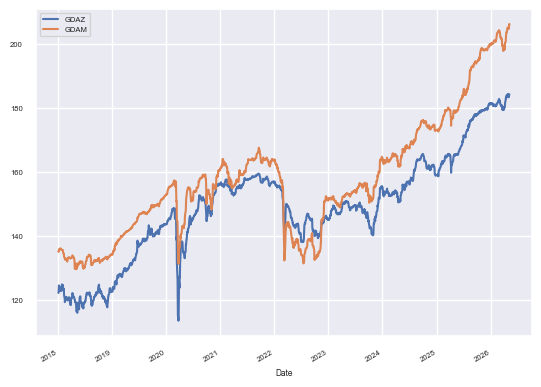

In [298]:
levels['ice_tri_levels'][['GDAZ','GDAM']].plot()

In [299]:
def log_returns(df):
    """
    Converts positive price/FX/index levels to log returns.
    """
    clean = df.where(df > 0)
    return np.log(clean).diff()


def bps_changes(df):
    """
    Converts percentage-point yield/rate changes to basis points.
    Example: 7.50 -> 7.60 becomes +10 bps.
    """
    return df.diff() * 100


def keep_existing(df, cols):
    """
    Keeps only columns that actually exist in the dataframe.
    """
    return df[[c for c in cols if c in df.columns]].copy()


def prefix(df, prefix_name):
    """
    Adds a clear prefix to all feature names.
    """
    return df.add_prefix(prefix_name)

## Economic blocks
Builds local, regional, and global return blocks before PCA.


In [301]:
# ============================================================
# LOCAL BLOCK
# ============================================================

local_currency_returns = log_returns(levels["FX"])

local_currency_returns = prefix(local_currency_returns, "LOCAL__CURRENCY__")


# TIBR changes
tibr_changes = bps_changes(levels["TIBR"])
tibr_changes = prefix(tibr_changes, "LOCAL__TIBR_BPS_CHG__")


# Georgia ICE government and sovereign TRI indices
ice_geo_gov_cols = ["G0GE", "GJGE", "GAGE", "G1GE", "G2GE", "G3GE", "G4GE"]
ice_geo_usd_cols = ["GDGE"]

ice_geo_cols = ice_geo_gov_cols + ice_geo_usd_cols

ice_geo_returns = log_returns(
    keep_existing(levels["ice_tri_levels"], ice_geo_cols)
)

ice_geo_returns = prefix(ice_geo_returns, "LOCAL__ICE_TRI__")


# Local bond yield changes
local_bond_isins = (
    bond_meta
    .loc[bond_meta["bond_region"] == "local_georgia", "isin"]
    .tolist()
)

local_bond_yields = keep_existing(levels["bond_yields_pct"], local_bond_isins)
local_bond_yield_changes = bps_changes(local_bond_yields)
local_bond_yield_changes = local_bond_yield_changes.rename(columns=bond_name_map)
local_bond_yield_changes = prefix(local_bond_yield_changes, "LOCAL__BOND_YLD_BPS_CHG__")


# Local equity volumes
# market_volumes are already log changes / log returns of volume
market_volume_raw = levels["market_volumes"].copy()

volume_name_map = {
    "BGEO.L": "BGEO",
    "TBCG.L": "TBCG",
    "CGEO.L": "CGEO",
    "AAZ.L": "AAZ",
    "AKBNK.IS": "AKBNK",
    "HSBK.L": "HSBK",
    "^FTMC": "FTMC",
    "BZ=F": "Brent",
    "GC=F": "Gold",
    "HG=F": "Copper",
    "BTC-USD": "BTC",
    "ETH-USD": "ETH"
}

market_volume_returns = market_volume_raw.rename(columns=volume_name_map)

local_volume_cols = ["BGEO", "TBCG", "CGEO"]

local_equity_volume = keep_existing(market_volume_returns, local_volume_cols)
local_equity_volume = prefix(local_equity_volume, "LOCAL__EQUITY_VOLUME__")


X_local = pd.concat(
    [
        local_currency_returns,
        tibr_changes,
        ice_geo_returns,
        local_bond_yield_changes,
        local_equity_volume
    ],
    axis=1
)

X_local = X_local.replace([np.inf, -np.inf], np.nan)

print("X_local:", X_local.shape)

X_local: (2174, 25)


In [302]:
# ============================================================
# REGIONAL BLOCK
# ============================================================

# Regional ICE USD sovereign TRI indices
ice_regional_cols = ["GDAM", "GDAZ", "GDRU", "GDTR"]

ice_regional_returns = log_returns(
    keep_existing(levels["ice_tri_levels"], ice_regional_cols)
)

ice_regional_returns = prefix(ice_regional_returns, "REGIONAL__ICE_TRI__")


# Regional bond yield changes
regional_bond_isins = (
    bond_meta
    .loc[bond_meta["bond_region"] == "regional", "isin"]
    .tolist()
)

regional_bond_yields = keep_existing(levels["bond_yields_pct"], regional_bond_isins)
regional_bond_yield_changes = bps_changes(regional_bond_yields)
regional_bond_yield_changes = regional_bond_yield_changes.rename(columns=bond_name_map)
regional_bond_yield_changes = prefix(regional_bond_yield_changes, "REGIONAL__BOND_YLD_BPS_CHG__")


# Regional market proxies
regional_market_cols = ["AKBNK", "BIST", "MOEX", "AAZ", "HSBK"]

regional_market_returns = log_returns(
    keep_existing(levels["all_market"], regional_market_cols)
)

regional_market_returns = prefix(regional_market_returns, "REGIONAL__MARKET__")


#Regional market volumes
regional_volume_cols = ["AKBNK", "BIST", "MOEX", "AAZ","HSBK"]

regional_market_volume = keep_existing(market_volume_returns, regional_volume_cols)
regional_market_volume = prefix(regional_market_volume, "REGIONAL__MARKET_VOLUME__")



X_regional = pd.concat(
    [
        ice_regional_returns,
        regional_bond_yield_changes,
        regional_market_returns,
        regional_market_volume
    ],
    axis=1
)

X_regional = X_regional.replace([np.inf, -np.inf], np.nan)

print("X_regional:", X_regional.shape)

X_regional: (2174, 26)


In [303]:
# ============================================================
# GLOBAL BLOCK
# ============================================================

# US Treasury yield changes
us_yield_changes = bps_changes(levels["yields"])
us_yield_changes = prefix(us_yield_changes, "GLOBAL__US_YIELD_BPS_CHG__")


# Commodities
commodity_returns = log_returns(levels["commodities"])
commodity_returns = prefix(commodity_returns, "GLOBAL__COMMODITY__")


# Crypto
crypto_returns = log_returns(levels["cryptos"])
crypto_returns = prefix(crypto_returns, "GLOBAL__CRYPTO__")


# Global equity
global_market_cols = ["EUFN", "IXG", "FM", "EEM", "FTMC"]

global_market_returns = log_returns(
    keep_existing(levels["all_market"], global_market_cols)
)

global_market_returns = prefix(global_market_returns, "GLOBAL__MARKET__")


# Global equity volumes
global_equity_volume_cols = ["EUFN", "IXG", "EEM",  "FTMC"]

global_equity_volume = keep_existing(market_volume_returns, global_equity_volume_cols)
global_equity_volume = prefix(global_equity_volume, "GLOBAL__EQUITY_VOLUME__")


#Commodity volumes
commodity_volume_cols = ["Brent", "Gold", "Copper"]

commodity_volume = keep_existing(market_volume_returns, commodity_volume_cols)
commodity_volume = prefix(commodity_volume, "GLOBAL__COMMODITY_VOLUME__")


# Crypto volumes
crypto_volume_cols = ["BTC", "ETH"]

crypto_volume = keep_existing(market_volume_returns, crypto_volume_cols)
crypto_volume = prefix(crypto_volume, "GLOBAL__CRYPTO_VOLUME__")


X_global = pd.concat(
    [
        us_yield_changes,
        commodity_returns,
        crypto_returns,
        global_market_returns,
        global_equity_volume,
        commodity_volume,
        crypto_volume
    ],
    axis=1
)

X_global = X_global.replace([np.inf, -np.inf], np.nan)

print("X_global:", X_global.shape)

X_global: (2174, 21)


In [304]:
# ============================================================
# FULL FEATURE MATRIX
# ============================================================

X_blocks = pd.concat(
    [
        X_local,
        X_regional,
        X_global
    ],
    axis=1
)

X_blocks = X_blocks.replace([np.inf, -np.inf], np.nan)

print("X_blocks shape:", X_blocks.shape)

X_blocks shape: (2174, 72)


In [305]:
feature_coverage = pd.DataFrame({
    "non_missing": X_blocks.notna().sum(),
    "missing": X_blocks.isna().sum(),
    "coverage": X_blocks.notna().mean()
}).sort_values("coverage")


print(X_blocks.shape)
feature_coverage.head(30)

(2174, 72)


,non_missing,missing,coverage
LOCAL__ICE_TRI__GAGE,69,2105,0.031739
LOCAL__BOND_YLD_BPS_CHG__Georgia__XS3262542155__mat2031,71,2103,0.032659
LOCAL__ICE_TRI__G2GE,91,2083,0.041858
LOCAL__ICE_TRI__G1GE,91,2083,0.041858
LOCAL__ICE_TRI__GJGE,91,2083,0.041858
LOCAL__ICE_TRI__G0GE,91,2083,0.041858
LOCAL__ICE_TRI__G4GE,91,2083,0.041858
LOCAL__ICE_TRI__G3GE,91,2083,0.041858
REGIONAL__BOND_YLD_BPS_CHG__Armenia__XS3020792696__mat2035,295,1879,0.135695
LOCAL__BOND_YLD_BPS_CHG__TBC_Bank__XS2808539410__mat2029,514,1660,0.236431


In [306]:
coverage_threshold = .80


coverage = X_blocks.notna().mean()


last_dates = X_blocks.apply(lambda col: col.last_valid_index())


cols_to_drop = [
    col for col in X_blocks.columns 
    if (coverage[col] < coverage_threshold)
]


X_blocks = X_blocks.drop(columns=cols_to_drop)
X_blocks.shape

(2174, 54)

## Georgian equity factor
Builds the common Georgian equity factor from BGEO, TBCG, and CGEO.


In [307]:
target_stocks = ["BGEO", "TBCG", "CGEO"]

target_prices = keep_existing(levels["all_market"], target_stocks)
target_log_prices = np.log(target_prices.where(target_prices > 0))

target_returns_1d = target_log_prices.diff()

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Individual 1 day Returns and 5D Forward Returns
indiv_1d = target_returns_1d.add_suffix('_1D')

# 2. PCA: Extract the "Systemic Georgia Factor"
# MLDP prefers PCA over simple means because it accounts for different volatilities
pca_data = target_returns_1d.dropna()
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_data)

pca = PCA(n_components=1)
pca_scores = pca.fit_transform(pca_scaled).flatten()

# --- THE FIX: SCALE TO ACTUAL RETURN MAGNITUDE ---
# Calculate the average volatility (std dev) of your actual stocks
avg_stock_vol = target_returns_1d.std().mean()

# Scale the factor so it has the same volatility as a typical Georgian stock
georgia_factor_return_scale = (pca_scores / np.std(pca_scores)) * avg_stock_vol

georgia_factor = pd.Series(
    georgia_factor_return_scale, 
    index=pca_data.index, 
    name="FACTOR_GEORGIA_PC1"
)

# 3. Structural Adjustment: "Clean CGEO"
# We subtract the BGEO component from CGEO to see the idiosyncratic move
# Clean_CGEO = Total_CGEO - (0.472 * BGEO)
cgeo_clean_1d = (target_returns_1d['CGEO'] - (0.472 * target_returns_1d['BGEO'])).rename("CGEO_RESIDUAL_1D")

# 4. Concatenate everything into a final Target Matrix
targets_final = pd.concat([
    indiv_1d, 
    georgia_factor, 
    cgeo_clean_1d
], axis=1)

# Check for multicollinearity (optional but recommended by MLDP)
print(f"Explained Variance of PC1: {pca.explained_variance_ratio_[0]:.2%}")
targets_final.tail()

Explained Variance of PC1: 64.56%


,BGEO_1D,TBCG_1D,CGEO_1D,FACTOR_GEORGIA_PC1,CGEO_RESIDUAL_1D
Date,,,,,
2026-05-04,0.000000,0.000000,0.000000,-0.000845,0.000000
2026-05-05,0.000921,-0.013519,-0.011681,-0.011140,-0.012116
2026-05-06,0.029934,-0.042578,0.007802,-0.002756,-0.006327
2026-05-07,0.013316,0.041727,0.009026,0.026266,0.002741
2026-05-08,-0.027717,-0.007692,-0.005148,-0.018064,0.007935


In [308]:
# ============================================================
# Georgian equity target
# Name kept as "Factor Georgia PC1" for dashboard consistency
# ============================================================

target_stocks = ["BGEO", "TBCG", "CGEO"]

target_prices = keep_existing(levels["all_market"], target_stocks)
target_prices = target_prices.replace([np.inf, -np.inf], np.nan)

target_log_prices = np.log(target_prices.where(target_prices > 0))
target_returns_1d = target_log_prices.diff()

# Equal-weight Georgian equity return
# This is not PCA, but we keep the dashboard/display name as Factor Georgia PC1.
factor_georgia_pc1 = (
    target_returns_1d[target_stocks]
    .dropna()
    .mean(axis=1)
    .rename("Factor Georgia PC1")
)

# Optional rebased performance index for visualization
factor_georgia_pc1_index = (
    100 * np.exp(factor_georgia_pc1.cumsum())
).rename("Factor Georgia PC1")

print("Target start:", factor_georgia_pc1.index.min())
print("Target end:", factor_georgia_pc1.index.max())
print("Target observations:", factor_georgia_pc1.shape[0])

factor_georgia_pc1.tail()

Target start: 2018-05-30 00:00:00
Target end: 2026-05-08 00:00:00
Target observations: 2059


Date
2026-05-04    0.000000
2026-05-05   -0.008093
2026-05-06   -0.001614
2026-05-07    0.021356
2026-05-08   -0.013519
Name: Factor Georgia PC1, dtype: float64

<Axes: xlabel='Date'>

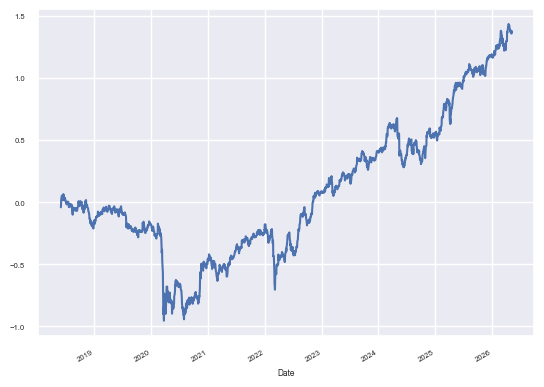

In [309]:
factor_georgia_pc1.cumsum().plot()

## PCA factor construction
Builds PCA factors from the economic blocks and keeps the selected factor set used later.


In [311]:
def feature_diagnostics(X):
    """
    Shows coverage and first/last valid date for each feature.
    """
    rows = []

    for col in X.columns:
        s = X[col]

        rows.append({
            "feature": col,
            "first_valid": s.first_valid_index(),
            "last_valid": s.last_valid_index(),
            "non_missing": s.notna().sum(),
            "missing": s.isna().sum(),
            "coverage": s.notna().mean()
        })

    return (
        pd.DataFrame(rows)
        .set_index("feature")
        .sort_values("coverage")
    )


def run_block_pca_safe(
    X_block,
    block_name,
    n_components=5,
    min_coverage=0.70,
    start=None,
    end=None,
    min_obs_warning=252
):
    """
    Safe PCA for financial data with structural missingness.

    Key idea:
    - Do not include very sparse features in the long sample.
    - Do not impute years before an asset/index existed.
    - Start PCA from the latest first-valid date among selected features.
    """

    Xw = X_block.copy()
    Xw = Xw.replace([np.inf, -np.inf], np.nan)

    if start is not None:
        Xw = Xw.loc[start:]

    if end is not None:
        Xw = Xw.loc[:end]

    diag = feature_diagnostics(Xw)

    kept_cols = diag.loc[diag["coverage"] >= min_coverage].index.tolist()
    dropped_cols = diag.loc[diag["coverage"] < min_coverage].index.tolist()

    if len(kept_cols) == 0:
        raise ValueError(f"No columns kept for {block_name}. Lower min_coverage or change sample window.")

    kept_first_valid = diag.loc[kept_cols, "first_valid"].dropna()

    pca_start = kept_first_valid.max()

    Xp = Xw.loc[pca_start:, kept_cols].copy()
    Xp = Xp.dropna(how="all")

    if Xp.shape[0] < min_obs_warning:
        print(
            f"Warning: {block_name} has only {Xp.shape[0]} observations. "
            f"This is okay for descriptive PCA, but weak for ML/backtesting."
        )

    n_components_actual = min(n_components, Xp.shape[0], Xp.shape[1])

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    pca = PCA(n_components=n_components_actual)

    X_imputed = imputer.fit_transform(Xp)
    X_scaled = scaler.fit_transform(X_imputed)

    scores_array = pca.fit_transform(X_scaled)

    pc_cols = [f"{block_name}_PC{i+1}" for i in range(n_components_actual)]

    scores = pd.DataFrame(
        scores_array,
        index=Xp.index,
        columns=pc_cols
    )

    loadings = pd.DataFrame(
        pca.components_.T,
        index=kept_cols,
        columns=pc_cols
    )

    explained_variance = pd.DataFrame({
        "PC": pc_cols,
        "explained_variance": pca.explained_variance_,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_variance_ratio": np.cumsum(pca.explained_variance_ratio_)
    })

    report = {
        "block": block_name,
        "scores": scores,
        "loadings": loadings,
        "explained_variance": explained_variance,
        "diagnostics": diag,
        "kept_cols": kept_cols,
        "dropped_cols": dropped_cols,
        "pca_start": pca_start,
        "pca_end": Xp.index.max(),
        "imputer": imputer,
        "scaler": scaler,
        "pca": pca
    }

    print(f"\n{block_name}")
    print("PCA start:", pca_start)
    print("PCA end:", Xp.index.max())
    print("Observations:", Xp.shape[0])
    print("Kept features:", len(kept_cols))
    print("Dropped features:", len(dropped_cols))

    return report

## Economic block definitions
Defines the grouped blocks used for PCA factor construction.


In [313]:
regional_ice_indices = X_regional[
    [c for c in X_regional.columns if "REGIONAL__ICE_TRI__" in c]
].copy()

russia_credit = X_regional[
    [
        c for c in X_regional.columns
        if (
            "Russia" in c
            or "REGIONAL__ICE_TRI__GDRU" in c
        )
    ]
].copy()

regional_bond_yields_ex_russia = X_regional[
    [
        c for c in X_regional.columns
        if (
            "REGIONAL__BOND_YLD_BPS_CHG__" in c
            and "Russia" not in c
        )
    ]
].copy()

# Optional: drop very sparse / short-history bond if needed
regional_bond_yields_ex_russia = regional_bond_yields_ex_russia.drop(
    columns=[
        c for c in [
            "REGIONAL__BOND_YLD_BPS_CHG__Armenia__XS3020792696__mat2035"
        ]
        if c in regional_bond_yields_ex_russia.columns
    ],
    errors="ignore"
)


In [314]:
economic_blocks = {}

# 1. Local currency
economic_blocks["LOCAL_CURRENCY"] = X_local[
    [c for c in X_local.columns if "LOCAL__CURRENCY__" in c]
]

# 2. Local interest rates
economic_blocks["LOCAL_RATES"] = X_local[
    [c for c in X_local.columns if "TIBR" in c]
]

# 3. Local credit
economic_blocks["LOCAL_CREDIT"] = X_local[
    [c for c in X_local.columns if "BOND_YLD" in c or "ICE_TRI" in c]
]

# 4. Local equity trading activity
economic_blocks["LOCAL_EQUITY_VOLUME"] = X_local[
    [c for c in X_local.columns if "EQUITY_VOLUME" in c]
]

# 5. Regional ICE bond indices
economic_blocks["REGIONAL_ICE_INDICES"] = regional_ice_indices.drop(columns=["REGIONAL__ICE_TRI__GDRU"])

# 6. Regional bond yields excluding Russia
economic_blocks["REGIONAL_BOND_YIELDS_EX_RUSSIA"] = regional_bond_yields_ex_russia

# 7. Russia credit
economic_blocks["RUSSIA_CREDIT"] = russia_credit.drop(columns=["REGIONAL__ICE_TRI__GDRU"])

# 8. Regional equities / market proxies
economic_blocks["REGIONAL_EQUITY"] = X_regional[
    [c for c in X_regional.columns if "REGIONAL__MARKET__" in c]
]

# 9. Regional market trading activity
economic_blocks["REGIONAL_MARKET_VOLUME"] = X_regional[
    [c for c in X_regional.columns if "MARKET_VOLUME" in c]
]

# 10. Global equities / risk appetite
economic_blocks["GLOBAL_EQUITY_RISK"] = X_global[
    [c for c in X_global.columns if "GLOBAL__MARKET__" in c]
]

# 11. Global equity trading activity
economic_blocks["GLOBAL_EQUITY_VOLUME"] = X_global[
    [c for c in X_global.columns if "GLOBAL__EQUITY_VOLUME__" in c]
]

# 12. US Treasury rates
economic_blocks["GLOBAL_RATES"] = X_global[
    [c for c in X_global.columns if "US_YIELD" in c]
]

# 13. Commodities
economic_blocks["COMMODITIES"] = X_global[
    [c for c in X_global.columns if "GLOBAL__COMMODITY__" in c]
]

# 14. Commodity trading activity
economic_blocks["COMMODITY_VOLUME"] = X_global[
    [c for c in X_global.columns if "COMMODITY_VOLUME" in c]
]

# 15. Crypto
economic_blocks["CRYPTO"] = X_global[
    [c for c in X_global.columns if "GLOBAL__CRYPTO__" in c]
]

# 16. Crypto trading activity
economic_blocks["CRYPTO_VOLUME"] = X_global[
    [c for c in X_global.columns if "CRYPTO_VOLUME" in c]
]


for name, block in economic_blocks.items():
    print(f"{name}: {block.shape}")

LOCAL_CURRENCY: (2174, 7)
LOCAL_RATES: (2174, 4)
LOCAL_CREDIT: (2174, 11)
LOCAL_EQUITY_VOLUME: (2174, 3)
REGIONAL_ICE_INDICES: (2174, 3)
REGIONAL_BOND_YIELDS_EX_RUSSIA: (2174, 7)
RUSSIA_CREDIT: (2174, 4)
REGIONAL_EQUITY: (2174, 5)
REGIONAL_MARKET_VOLUME: (2174, 5)
GLOBAL_EQUITY_RISK: (2174, 4)
GLOBAL_EQUITY_VOLUME: (2174, 4)
GLOBAL_RATES: (2174, 3)
COMMODITIES: (2174, 3)
COMMODITY_VOLUME: (2174, 3)
CRYPTO: (2174, 2)
CRYPTO_VOLUME: (2174, 2)


In [315]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. Isolate the regional bond yields
bond_yields = economic_blocks['REGIONAL_BOND_YIELDS_EX_RUSSIA'].copy()

# 2. Use IterativeImputer
# It uses Turkey (which is present) to estimate Armenia/Azerbaijan 
# based on the periods where they all overlap.
imputer = IterativeImputer(max_iter=10, random_state=42)
economic_blocks['REGIONAL_BOND_YIELDS_EX_RUSSIA'] = pd.DataFrame(
    imputer.fit_transform(bond_yields), 
    index=bond_yields.index, 
    columns=bond_yields.columns
)


D:\Anaconda\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning:

[IterativeImputer] Early stopping criterion not reached.



<Axes: xlabel='Date'>

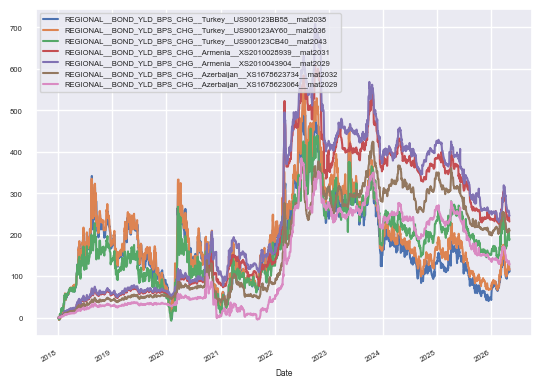

In [316]:
economic_blocks['REGIONAL_BOND_YIELDS_EX_RUSSIA'].cumsum().plot()

In [317]:
def pca_block_summary(X_block, block_name, min_coverage=0.70, n_components=5):
    report = run_block_pca_safe(
        X_block,
        block_name=block_name,
        n_components=n_components,
        min_coverage=min_coverage
    )

    ev = report["explained_variance"].copy()
    ev["block"] = block_name
    ev["n_features"] = len(report["kept_cols"])
    ev["pca_start"] = report["pca_start"]
    ev["pca_end"] = report["pca_end"]

    return report, ev


pca_reports = {}
pca_summaries = []

for name, block in economic_blocks.items():
    if block.shape[1] < 2:
        print(f"Skipping {name}: fewer than 2 features")
        continue

    try:
        report, summary = pca_block_summary(
            block,
            block_name=name,
            min_coverage=0.80,
            n_components=5
        )

        pca_reports[name] = report
        pca_summaries.append(summary)

    except Exception as e:
        print(f"{name} failed: {e}")

pca_summary_table = pd.concat(pca_summaries, ignore_index=True)
pca_summary_table


LOCAL_CURRENCY
PCA start: 2018-01-02 00:00:00
PCA end: 2026-05-08 00:00:00
Observations: 2173
Kept features: 7
Dropped features: 0

LOCAL_RATES
PCA start: 2019-03-14 00:00:00
PCA end: 2026-05-08 00:00:00
Observations: 1861
Kept features: 4
Dropped features: 0
LOCAL_CREDIT failed: No columns kept for LOCAL_CREDIT. Lower min_coverage or change sample window.

LOCAL_EQUITY_VOLUME
PCA start: 2018-05-29 00:00:00
PCA end: 2026-05-08 00:00:00
Observations: 1815
Kept features: 3
Dropped features: 0

REGIONAL_ICE_INDICES
PCA start: 2018-01-03 00:00:00
PCA end: 2026-05-08 00:00:00
Observations: 2134
Kept features: 3
Dropped features: 0

REGIONAL_BOND_YIELDS_EX_RUSSIA
PCA start: 2018-01-01 00:00:00
PCA end: 2026-05-08 00:00:00
Observations: 2174
Kept features: 7
Dropped features: 0

RUSSIA_CREDIT
PCA start: 2018-01-02 00:00:00
PCA end: 2026-05-08 00:00:00
Observations: 2167
Kept features: 3
Dropped features: 1

REGIONAL_EQUITY
PCA start: 2018-01-04 00:00:00
PCA end: 2026-05-08 00:00:00
Observati

,PC,explained_variance,explained_variance_ratio,cumulative_variance_ratio,block,n_features,pca_start,pca_end
0,LOCAL_CURRENCY_PC1,4.108652,0.586680,0.586680,LOCAL_CURRENCY,7,2018-01-02,2026-05-08
1,LOCAL_CURRENCY_PC2,0.974967,0.139217,0.725897,LOCAL_CURRENCY,7,2018-01-02,2026-05-08
2,LOCAL_CURRENCY_PC3,0.800923,0.114365,0.840262,LOCAL_CURRENCY,7,2018-01-02,2026-05-08
3,LOCAL_CURRENCY_PC4,0.457780,0.065367,0.905629,LOCAL_CURRENCY,7,2018-01-02,2026-05-08
4,LOCAL_CURRENCY_PC5,0.381739,0.054509,0.960138,LOCAL_CURRENCY,7,2018-01-02,2026-05-08
5,LOCAL_RATES_PC1,2.287458,0.571557,0.571557,LOCAL_RATES,4,2019-03-14,2026-05-08
6,LOCAL_RATES_PC2,0.999591,0.249763,0.821321,LOCAL_RATES,4,2019-03-14,2026-05-08
7,LOCAL_RATES_PC3,0.534255,0.133492,0.954813,LOCAL_RATES,4,2019-03-14,2026-05-08
8,LOCAL_RATES_PC4,0.180846,0.045187,1.000000,LOCAL_RATES,4,2019-03-14,2026-05-08
9,LOCAL_EQUITY_VOLUME_PC1,1.301625,0.433636,0.433636,LOCAL_EQUITY_VOLUME,3,2018-05-29,2026-05-08


In [318]:
X_economic_pca_factors = pd.concat(
    [report["scores"] for report in pca_reports.values()],
    axis=1
).sort_index()
X_economic_pca_factors = X_economic_pca_factors.ffill(limit=5).dropna()
X_economic_pca_factors.head()

,LOCAL_CURRENCY_PC1,LOCAL_CURRENCY_PC2,LOCAL_CURRENCY_PC3,LOCAL_CURRENCY_PC4,LOCAL_CURRENCY_PC5,LOCAL_RATES_PC1,LOCAL_RATES_PC2,LOCAL_RATES_PC3,LOCAL_RATES_PC4,LOCAL_EQUITY_VOLUME_PC1,...,COMMODITIES_PC1,COMMODITIES_PC2,COMMODITIES_PC3,COMMODITY_VOLUME_PC1,COMMODITY_VOLUME_PC2,COMMODITY_VOLUME_PC3,CRYPTO_PC1,CRYPTO_PC2,CRYPTO_VOLUME_PC1,CRYPTO_VOLUME_PC2
Date,,,,,,,,,,,,,,,,,,,,,
2019-03-14,1.067257,-0.545603,-0.506580,1.645223,0.435169,-0.554720,-1.618690,0.149153,-0.209911,1.392441,...,-1.385728,0.504439,-0.032203,0.281020,-0.134944,0.149494,0.103018,-0.026819,0.412858,0.153876
2019-03-15,-0.759661,1.071111,0.156256,-0.086652,0.267355,-1.259777,0.342105,0.167297,-0.418875,1.199881,...,0.510170,-0.366696,-0.084313,0.516256,0.669279,-1.579177,0.533094,0.235922,-0.296315,-0.326442
2019-03-18,0.244749,0.240441,-0.419017,0.193617,0.217486,-1.625830,-0.276951,-0.232212,-0.207464,-3.050187,...,-0.014442,0.266296,0.012232,-0.428721,-0.521457,0.152393,0.455848,-0.145242,0.095791,0.048308
2019-03-19,0.233774,0.096245,0.049071,-0.313630,0.037948,-0.779221,0.009937,0.015565,-0.171639,0.099875,...,0.402084,-0.152476,0.062340,0.659709,0.275015,0.064834,0.255852,-0.051112,-0.283619,0.098655
2019-03-20,0.204172,0.779426,0.651625,-0.127288,0.434497,-0.403627,-0.022127,0.551496,-0.382060,0.343609,...,-0.071025,0.629897,-0.019801,-0.888484,-0.252676,0.771593,0.064995,-0.046710,0.488584,-0.013819


### Selected PCA factor set
Keeps the parsimonious factor set used by the diagnostic and predictive checks.


In [319]:
selected_pcs_parsimonious = [
    # PC1-PC3 captures 84% of variance. 
    "LOCAL_CURRENCY_PC1", 
    "LOCAL_CURRENCY_PC2",
    "LOCAL_CURRENCY_PC3",

    # LOCAL RATES (Georgia Refinancing/TIBR)
    # PC1-PC2 captures 82%. 
    # Direct impact on Net Interest Margins (NIM) for TBCG/BGEO.
    #"LOCAL_RATES_PC1",
    "LOCAL_RATES_PC2",

    # LOCAL EQUITY VOLUME
    # PC1-PC2 captures 75%. 
    # Vital for validating CUSUM triggers in Georgian stocks.
    #"LOCAL_EQUITY_VOLUME_PC1",
    #"LOCAL_EQUITY_VOLUME_PC2",

    # REGIONAL CREDIT & INDICES (The "Caucasus/Turkey/Russia" Risk)
    # RUSSIA_CREDIT PC1 is a powerhouse (85% variance).
    # Bond Yields (Ex-Russia) PC1-PC3 captures 80%.
    #"RUSSIA_CREDIT_PC1",
    #"REGIONAL_BOND_YIELDS_EX_RUSSIA_PC1",
    #"REGIONAL_BOND_YIELDS_EX_RUSSIA_PC2",
    #"REGIONAL_BOND_YIELDS_EX_RUSSIA_PC3",
    "REGIONAL_ICE_INDICES_PC1",

    # REGIONAL EQUITY & VOLUME
    # PC1-PC3 captures 77% of price moves and 72% of volume moves.
    "REGIONAL_EQUITY_PC1",
    "REGIONAL_EQUITY_PC2",
    "REGIONAL_EQUITY_PC3",
    "REGIONAL_MARKET_VOLUME_PC1",
    #"REGIONAL_MARKET_VOLUME_PC2",
    #"REGIONAL_MARKET_VOLUME_PC3",

    # GLOBAL EQUITY RISK (S&P 500 / MSCI EM)
    # PC1-PC2 captures 90% of the global "Risk-On" sentiment.
    "GLOBAL_EQUITY_RISK_PC1",
    "GLOBAL_EQUITY_RISK_PC2",
    
    # GLOBAL EQUITY VOLUME
    # PC1-PC3 captures 80% of global turnover shocks.
    #"GLOBAL_EQUITY_VOLUME_PC1",
    #"GLOBAL_EQUITY_VOLUME_PC2",
    #"GLOBAL_EQUITY_VOLUME_PC3",

    # GLOBAL RATES (US 10Y / G7 Yields)
    # PC1-PC2 captures a massive 98% of variance.
    "GLOBAL_RATES_PC1",
    "GLOBAL_RATES_PC2",

    # COMMODITIES (Gold, Oil, Copper)
    # PC1-PC2 captures 78% of price and 76% of volume.
    "COMMODITIES_PC1",
    "COMMODITIES_PC2",
    "COMMODITY_VOLUME_PC1",
    "COMMODITY_VOLUME_PC2",

    # CRYPTO
    # 90%+ variance captured in the first component of both price and volume.
    "CRYPTO_PC1",
    "CRYPTO_VOLUME_PC1"
]

X_selected_parsimonious = X_economic_pca_factors[selected_pcs_parsimonious].copy()
X_selected_parsimonious.shape

(1848, 19)

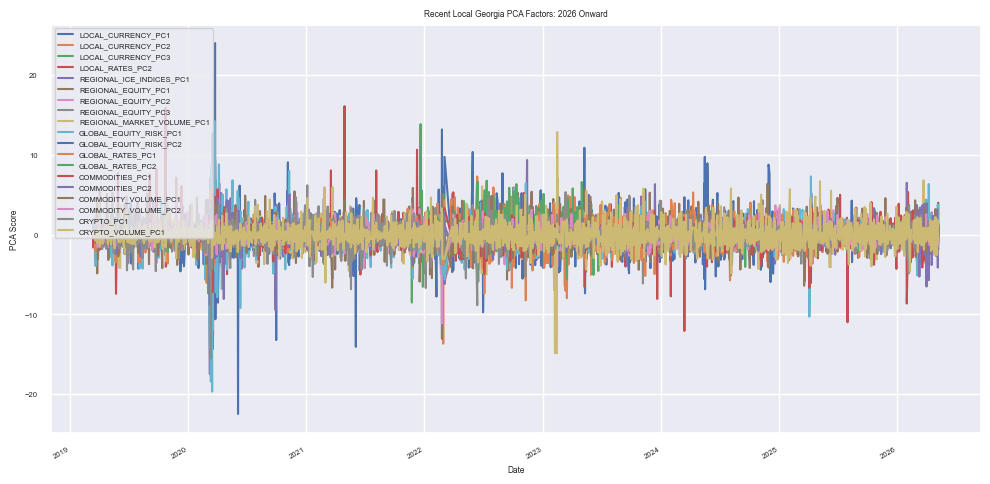

In [320]:
X_selected_parsimonious.plot(figsize=(12, 6))

plt.title("Recent Local Georgia PCA Factors: 2026 Onward")
plt.ylabel("PCA Score")
plt.grid(True)
plt.show()

In [321]:
def check_lagged_coverage(df):
    stats = pd.DataFrame({
        'total_rows': len(df),
        'missing_values': df.isna().sum(),
        'coverage_pct': (df.notna().mean() * 100).round(2),
    })
    return stats.sort_values("coverage_pct", ascending=False)

# Run it
pca_diag = check_lagged_coverage(X_selected_parsimonious)
print(pca_diag)

                            total_rows  missing_values  coverage_pct
LOCAL_CURRENCY_PC1                1848               0         100.0
GLOBAL_EQUITY_RISK_PC2            1848               0         100.0
CRYPTO_PC1                        1848               0         100.0
COMMODITY_VOLUME_PC2              1848               0         100.0
COMMODITY_VOLUME_PC1              1848               0         100.0
COMMODITIES_PC2                   1848               0         100.0
COMMODITIES_PC1                   1848               0         100.0
GLOBAL_RATES_PC2                  1848               0         100.0
GLOBAL_RATES_PC1                  1848               0         100.0
GLOBAL_EQUITY_RISK_PC1            1848               0         100.0
LOCAL_CURRENCY_PC2                1848               0         100.0
REGIONAL_MARKET_VOLUME_PC1        1848               0         100.0
REGIONAL_EQUITY_PC3               1848               0         100.0
REGIONAL_EQUITY_PC2               

<Axes: xlabel='Date'>

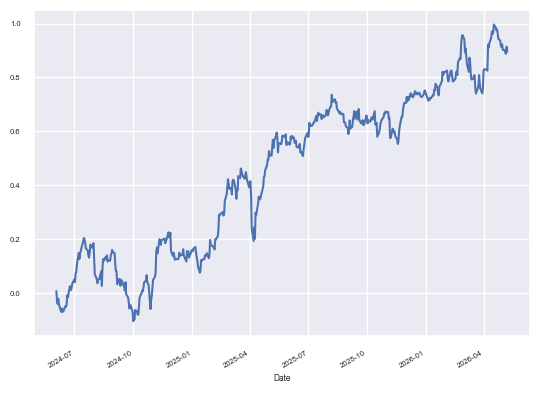

In [322]:
targets_final['FACTOR_GEORGIA_PC1'].tail(500).cumsum().plot()

In [323]:
            #X_economic_pca_factors X_selected_parsimonious
X_core_pca = X_selected_parsimonious.shift(0)
#X_core_pca = pd.concat(
#    [
#        X_selected_parsimonious,
#        #targets_final["FACTOR_GEORGIA_PC1"].rename("FACTOR_GEORGIA_PC1_SHIFTED"),
#        targets_final["BGEO_1D"].rename("BGEO_1D_SHIFTED"),
#        targets_final["TBCG_1D"].rename("TBCG_1D_SHIFTED"),
#        #targets_final["CGEO_1D"].rename("CGEO_1D_SHIFTED"),
#        targets_final["CGEO_RESIDUAL_1D"].rename("CGEO_RESIDUAL_1D_SHIFTED")
#    ], axis=1).shift(1)

model_data_core_pca = pd.concat(
    [
        targets_final,
        X_core_pca
    ],
    axis=1
).dropna()

y = model_data_core_pca["FACTOR_GEORGIA_PC1"]
X = model_data_core_pca.drop(columns=["FACTOR_GEORGIA_PC1","BGEO_1D","TBCG_1D","CGEO_1D","CGEO_RESIDUAL_1D",
                                     ])

print("Model data shape:", model_data_core_pca.shape)
print("Start:", model_data_core_pca.index.min())
print("End:", model_data_core_pca.index.max())

model_data_core_pca.head(1)

Model data shape: (1840, 24)
Start: 2019-03-14 00:00:00
End: 2026-05-08 00:00:00


,BGEO_1D,TBCG_1D,CGEO_1D,FACTOR_GEORGIA_PC1,CGEO_RESIDUAL_1D,LOCAL_CURRENCY_PC1,LOCAL_CURRENCY_PC2,LOCAL_CURRENCY_PC3,LOCAL_RATES_PC2,REGIONAL_ICE_INDICES_PC1,...,GLOBAL_EQUITY_RISK_PC1,GLOBAL_EQUITY_RISK_PC2,GLOBAL_RATES_PC1,GLOBAL_RATES_PC2,COMMODITIES_PC1,COMMODITIES_PC2,COMMODITY_VOLUME_PC1,COMMODITY_VOLUME_PC2,CRYPTO_PC1,CRYPTO_VOLUME_PC1
Date,,,,,,,,,,,,,,,,,,,,,
2019-03-14,0.009694,0.008844,-0.023176,-0.002885,-0.027751,1.067257,-0.545603,-0.50658,-1.61869,0.108947,...,0.239835,0.572785,0.382602,-0.165706,-1.385728,0.504439,0.28102,-0.134944,0.103018,0.412858


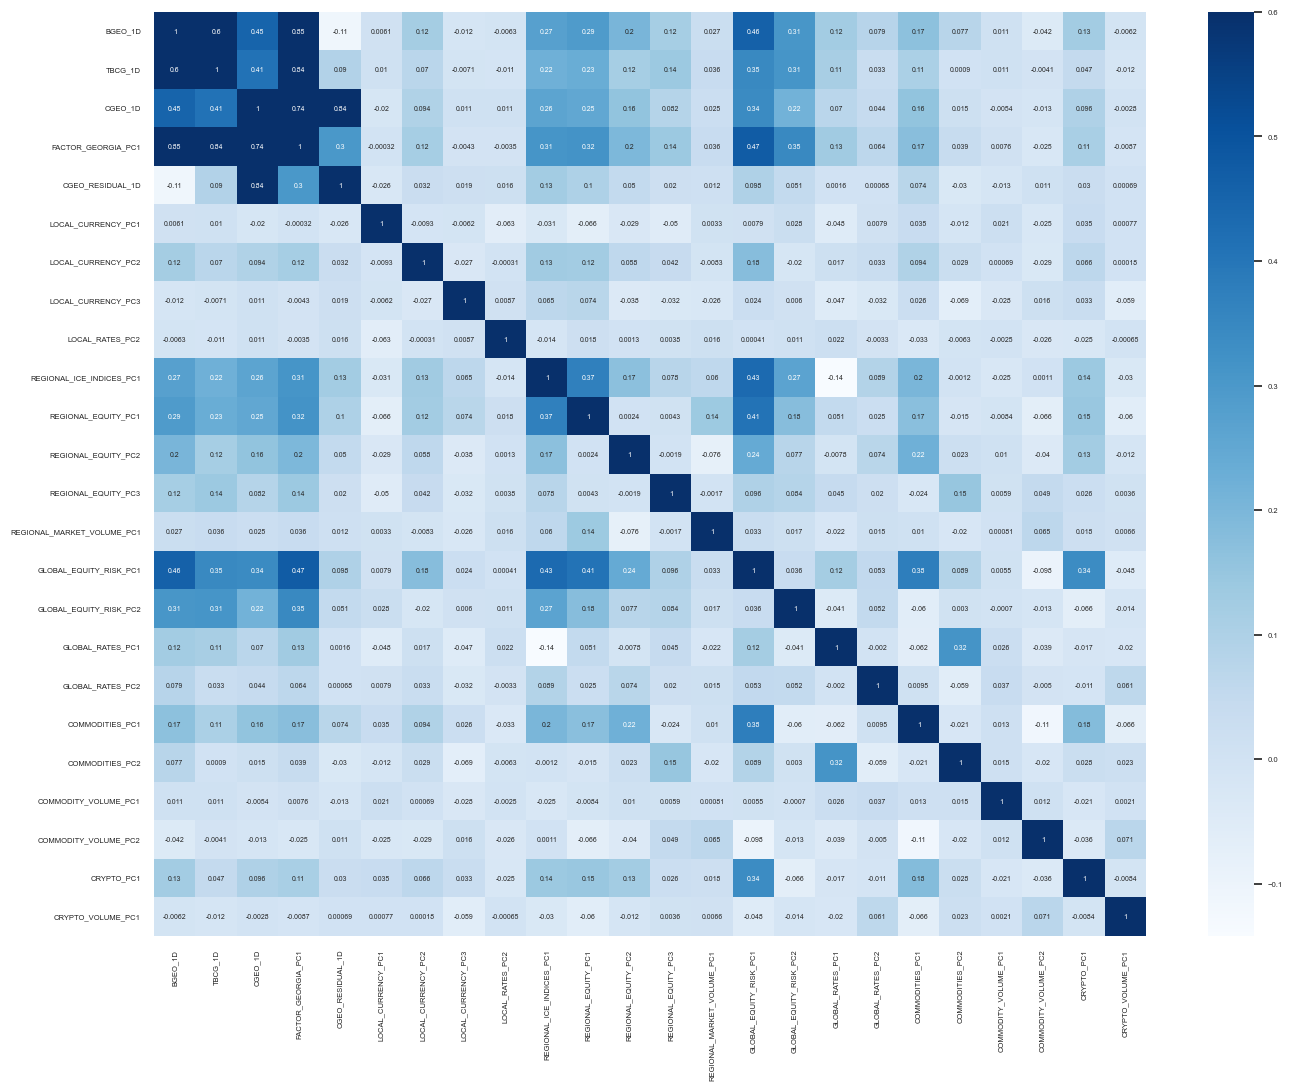

In [324]:
# Correlation check for daily FX returns.
plt.figure(figsize=(16,12))
sns.set(font_scale=0.5)
sns.heatmap(model_data_core_pca.corr(), cmap="Blues", annot=True, annot_kws={"size":5}, vmax =0.6)
plt.show()

## Same-day diagnostic model
Lasso is used here for same-day attribution. This explains co-movement, not next-day prediction.


In [326]:
def evaluate_predictions(y_true, y_pred, model_name):
    y_true = pd.Series(y_true).copy()
    y_pred = pd.Series(y_pred, index=y_true.index).copy()

    return {
        "model": model_name,
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "corr": y_true.corr(y_pred),
        "direction_accuracy": (np.sign(y_true) == np.sign(y_pred)).mean()
    }

In [519]:
split_date = pd.Timestamp("2026-01-01")

X_train = X.loc[X.index < split_date].copy()
y_train = y.loc[y.index < split_date].copy()

X_test = X.loc[X.index >= split_date].copy()
y_test = y.loc[y.index >= split_date].copy()

print("Train:", X_train.index.min(), X_train.index.max(), X_train.shape)
print("Test:", X_test.index.min(), X_test.index.max(), X_test.shape)

Train: 2019-03-14 00:00:00 2025-12-31 00:00:00 (1749, 19)
Test: 2026-01-02 00:00:00 2026-05-08 00:00:00 (91, 19)


In [328]:
y_test

Date
2025-01-02   -0.003472
2025-01-03    0.009660
2025-01-06    0.005691
2025-01-07   -0.019313
2025-01-08   -0.016445
                ...   
2026-05-04   -0.000845
2026-05-05   -0.011140
2026-05-06   -0.002756
2026-05-07    0.026266
2026-05-08   -0.018064
Name: FACTOR_GEORGIA_PC1, Length: 348, dtype: float64

In [329]:
tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Mean Benchmark": None,

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(
            alphas=np.logspace(-5, 5, 200),
            cv=tscv
        ))
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LassoCV(
            alphas=np.logspace(-6, 1, 200),
            cv=tscv,
            max_iter=100000,
            random_state=0
        ))
    ]),

    "Elastic Net": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            alphas=np.logspace(-6, 1, 200),
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            cv=tscv,
            max_iter=100000,
            random_state=0
        ))
    ])
}

results = []
predictions = pd.DataFrame(index=y_test.index)
predictions["actual"] = y_test

fitted_models = {}

for name, model in models.items():

    if name == "Mean Benchmark":
        y_pred = pd.Series(y_train.mean(), index=y_test.index, name=name)

    else:
        model.fit(X_train, y_train)
        fitted_models[name] = model

        y_pred = pd.Series(
            model.predict(X_test),
            index=y_test.index,
            name=name
        )

    predictions[name] = y_pred

    results.append(
        evaluate_predictions(y_test, y_pred, name)
    )

results_df = pd.DataFrame(results).sort_values("rmse")
results_df

,model,rmse,mae,r2,corr,direction_accuracy
1,Linear Regression,0.018284,0.013690,0.369802,6.439105e-01,0.623563
3,Lasso,0.018316,0.013683,0.367597,6.499168e-01,0.629310
4,Elastic Net,0.018316,0.013683,0.367597,6.499168e-01,0.629310
2,Ridge,0.018573,0.013875,0.349771,6.398624e-01,0.629310
0,Mean Benchmark,0.023176,0.016674,-0.012500,-3.462832e-18,0.471264


### Ridge block check
A Ridge check is kept as a benchmark for block-level explanatory power.


In [331]:
def run_block_ablation(X, y, block_prefixes, split_date="2025-01-01"):
    results = []
    predictions_by_block = {}

    split_date = pd.Timestamp(split_date)
    tscv = TimeSeriesSplit(n_splits=5)

    for block_name, prefixes in block_prefixes.items():
        cols = [
            c for c in X.columns
            if any(c.startswith(prefix) for prefix in prefixes)
        ]

        if len(cols) == 0:
            continue

        X_block = X[cols].copy()

        X_train = X_block.loc[X_block.index < split_date]
        y_train = y.loc[y.index < split_date]

        X_test = X_block.loc[X_block.index >= split_date]
        y_test = y.loc[y.index >= split_date]

        common_train = X_train.index.intersection(y_train.index)
        common_test = X_test.index.intersection(y_test.index)

        X_train = X_train.loc[common_train]
        y_train = y_train.loc[common_train]

        X_test = X_test.loc[common_test]
        y_test = y_test.loc[common_test]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(
                alphas=np.logspace(-5, 5, 200),
                cv=tscv
            ))
        ])



        model.fit(X_train, y_train)

        pred = pd.Series(
            model.predict(X_test),
            index=y_test.index,
            name=block_name
        )

        predictions_by_block[block_name] = pred

        result = evaluate_predictions(
            y_test,
            pred,
            block_name
        )

        result["n_features"] = len(cols)
        result["selected_alpha"] = model.named_steps["model"].alpha_

        results.append(result)

    results_df = pd.DataFrame(results).sort_values("r2", ascending=False)

    return results_df, predictions_by_block

### Lasso block attribution
Lasso results are kept because they support the attribution dashboard.


In [333]:
def run_block_ablation(X, y, block_prefixes, split_date="2025-01-01"):
    results = []
    predictions_by_block = {}

    split_date = pd.Timestamp(split_date)
    tscv = TimeSeriesSplit(n_splits=5)

    for block_name, prefixes in block_prefixes.items():
        cols = [
            c for c in X.columns
            if any(c.startswith(prefix) for prefix in prefixes)
        ]

        if len(cols) == 0:
            continue

        X_block = X[cols].copy()

        X_train = X_block.loc[X_block.index < split_date]
        y_train = y.loc[y.index < split_date]

        X_test = X_block.loc[X_block.index >= split_date]
        y_test = y.loc[y.index >= split_date]

        common_train = X_train.index.intersection(y_train.index)
        common_test = X_test.index.intersection(y_test.index)

        X_train = X_train.loc[common_train]
        y_train = y_train.loc[common_train]

        X_test = X_test.loc[common_test]
        y_test = y_test.loc[common_test]


        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LassoCV(
                alphas=np.logspace(-5, 1, 100), 
                cv=tscv,
                max_iter=10000,              
                random_state=42
            ))
        ])

        model.fit(X_train, y_train)

        pred = pd.Series(
            model.predict(X_test),
            index=y_test.index,
            name=block_name
        )

        predictions_by_block[block_name] = pred

        result = evaluate_predictions(
            y_test,
            pred,
            block_name
        )

        n_nonzero = np.sum(model.named_steps["model"].coef_ != 0)

        result["n_features_total"] = len(cols)
        result["n_features_active"] = n_nonzero
        result["selected_alpha"] = model.named_steps["model"].alpha_

        results.append(result)

    results_df = pd.DataFrame(results).sort_values("r2", ascending=False)

    return results_df, predictions_by_block

In [334]:
block_prefixes = {
    # --- Individual Factor Blocks (Cleaned) ---
    "LOCAL_CURRENCY": ["LOCAL_CURRENCY_"],
    "LOCAL_RATES": ["LOCAL_RATES_"],
    
    "REGIONAL_ICE_INDICES": ["REGIONAL_ICE_INDICES_"],
    "REGIONAL_EQUITY": ["REGIONAL_EQUITY_"],
    "REGIONAL_MARKET_VOLUME": ["REGIONAL_MARKET_VOLUME_"],

    "GLOBAL_EQUITY_RISK": ["GLOBAL_EQUITY_RISK_"],
    "GLOBAL_RATES": ["GLOBAL_RATES_"],

    "COMMODITIES": ["COMMODITIES_"],
    "COMMODITY_VOLUME": ["COMMODITY_VOLUME_"],

    "CRYPTO": ["CRYPTO_PC"],        # FIX: Changed from "CRYPTO" to "CRYPTO_PC"
    "CRYPTO_VOLUME": ["CRYPTO_VOLUME_"],

    # --- Composite Blocks ---
    "VOLUME_ALL": [
        "REGIONAL_MARKET_VOLUME_",
        "COMMODITY_VOLUME_",
        "CRYPTO_VOLUME_"
    ],

    "PRICE_MACRO_ALL": [
        "LOCAL_CURRENCY_",
        "LOCAL_RATES_",
        "REGIONAL_ICE_INDICES_",
        "REGIONAL_EQUITY_",
        "GLOBAL_EQUITY_RISK_",
        "GLOBAL_RATES_",
        "COMMODITIES_",
        "CRYPTO_PC" # FIX: Keep it clean here too
    ],

    # The "Optimized" Model (Based on your high R2 categories)
    "OPTIMIZED_MODEL": [
        "GLOBAL_EQUITY_RISK_",
        "REGIONAL_ICE_INDICES_",
        "REGIONAL_EQUITY_"
    ],

    "ALL_SELECTED": [
        "LOCAL_CURRENCY_",
        "LOCAL_RATES_",
        "REGIONAL_ICE_INDICES_",
        "REGIONAL_EQUITY_",
        "REGIONAL_MARKET_VOLUME_",
        "GLOBAL_EQUITY_RISK_",
        "GLOBAL_RATES_",
        "COMMODITIES_",
        "COMMODITY_VOLUME_",
        "CRYPTO_PC",
        "CRYPTO_VOLUME_"
    ]
}

In [335]:
#Lasso

block_ablation_results, predictions_by_block = run_block_ablation(
    X=X,
    y=y,
    block_prefixes=block_prefixes,
    split_date="2025-01-01"
)

block_ablation_results

,model,rmse,mae,r2,corr,direction_accuracy,n_features_total,n_features_active,selected_alpha
5,GLOBAL_EQUITY_RISK,0.017796,0.013099,0.402983,6.782695e-01,0.681034,2,2,0.000010
13,OPTIMIZED_MODEL,0.018099,0.013494,0.382512,6.614657e-01,0.640805,6,5,0.000285
12,PRICE_MACRO_ALL,0.018284,0.013708,0.369805,6.502570e-01,0.632184,15,12,0.000215
14,ALL_SELECTED,0.018316,0.013683,0.367648,6.494580e-01,0.629310,19,15,0.000248
2,REGIONAL_ICE_INDICES,0.021696,0.015885,0.112667,4.340263e-01,0.563218,1,1,0.000010
3,REGIONAL_EQUITY,0.021954,0.016611,0.091429,3.191785e-01,0.548851,3,3,0.000010
9,CRYPTO,0.023069,0.016561,-0.003141,1.537452e-01,0.534483,1,1,0.001520
0,LOCAL_CURRENCY,0.023143,0.016683,-0.009595,5.907770e-02,0.471264,3,1,0.002310
1,LOCAL_RATES,0.023176,0.016674,-0.012500,-3.462832e-18,0.471264,1,0,10.000000
4,REGIONAL_MARKET_VOLUME,0.023176,0.016674,-0.012500,-3.462832e-18,0.471264,1,0,10.000000


In [336]:
# Updated to include only the active prefixes in your parsimonious list
factor_name_map = {
    # Macro / Price Factors
    "GLOBAL_EQUITY_RISK": "Global equities",
    "GLOBAL_RATES": "US Treasury rates",
    "REGIONAL_EQUITY": "Regional equities",
    "REGIONAL_ICE_INDICES": "Regional ICE bond indices",
    "LOCAL_CURRENCY": "Local currency",
    "LOCAL_RATES": "Local interest rates",
    "COMMODITIES": "Commodities",
    "CRYPTO": "Crypto",

    # Volume Factors
    "REGIONAL_MARKET_VOLUME": "Regional market volumes",
    "COMMODITY_VOLUME": "Commodity volumes",
    "CRYPTO_VOLUME": "Crypto volumes",
    
    # Composite Blocks (for the Ablation Results)
    "PRICE_MACRO_ALL": "All Price Factors",
    "VOLUME_ALL": "All Volume Factors",
    "REGIONAL_ALL": "All Regional Factors",
    "ALL_SELECTED": "Full Parsimonious Model"
}

# Ordered from most global/macro to specific/volume shocks
factor_order = [
    "Full Parsimonious Model",
    "All Price Factors",
    "All Regional Factors",
    "Global equities",
    "US Treasury rates",
    "Regional equities",
    "Regional ICE bond indices",
    "Local currency",
    "Local interest rates",
    "Commodities",
    "Crypto",
    "All Volume Factors",
    "Regional market volumes",
    "Commodity volumes",
    "Crypto volumes"
]

In [337]:
def lasso_factor_attribution(
    X,
    y,
    factor_name_map,
    factor_order,
    split_date="2025-01-01",
    alphas=np.logspace(-5, 1, 100) # Adjusted range for Lasso
):
    split_date = pd.Timestamp(split_date)

    # 1. Train/Test Split
    X_train = X.loc[X.index < split_date].copy()
    y_train = y.loc[y.index < split_date].copy()
    X_test = X.loc[X.index >= split_date].copy()
    y_test = y.loc[y.index >= split_date].copy()

    common_train = X_train.index.intersection(y_train.index)
    common_test = X_test.index.intersection(y_test.index)

    X_train, y_train = X_train.loc[common_train], y_train.loc[common_train]
    X_test, y_test = X_test.loc[common_test], y_test.loc[common_test]

    # 2. Build Lasso Pipeline
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LassoCV(
            alphas=alphas,
            cv=TimeSeriesSplit(n_splits=5),
            max_iter=10000,   # Lasso needs more iterations to converge
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    scaler = model.named_steps["scaler"]
    lasso = model.named_steps["model"]

    # 3. Calculate Feature Contributions
    # Contribution = Scaled Feature Value * Coefficient
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        index=X_test.index,
        columns=X_test.columns
    )

    # Multiply each column by its corresponding lasso coefficient
    feature_contrib = X_test_scaled.mul(lasso.coef_, axis=1)

    # 4. Aggregate Contributions by Factor Block
    block_contrib = pd.DataFrame(index=X_test.index)

    for prefix, clean_name in factor_name_map.items():
        # Find all PCs belonging to this prefix (e.g., PC1, PC2, PC3)
        cols = [c for c in feature_contrib.columns if c.startswith(prefix)]
        
        if len(cols) > 0:
            block_contrib[clean_name] = feature_contrib[cols].sum(axis=1)

    # Sort columns based on your preferred order
    existing_order = [c for c in factor_order if c in block_contrib.columns]
    block_contrib = block_contrib[existing_order]

    # 5. Predictions and Metrics
    intercept = lasso.intercept_
    y_pred = block_contrib.sum(axis=1) + intercept
    y_pred.name = "Predicted"

    # Count how many features Lasso actually kept (non-zero)
    n_active = np.sum(lasso.coef_ != 0)

    metrics = {
        "r2": r2_score(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "mae": mean_absolute_error(y_test, y_pred),
        "corr": y_test.corr(y_pred),
        "selected_alpha": lasso.alpha_,
        "intercept": intercept,
        "n_features_active": n_active,
        "n_features_total": len(lasso.coef_)
    }

    return {
        "model": model,
        "y_test": y_test,
        "y_pred": y_pred,
        "feature_contrib": feature_contrib,
        "block_contrib": block_contrib,
        "metrics": metrics
    }

In [338]:
def ridge_factor_attribution(
    X,
    y,
    factor_name_map,
    split_date="2026-01-01",
    alphas=np.logspace(-5, 5, 200)
    ):
    split_date = pd.Timestamp(split_date)
    X_train = X.loc[X.index < split_date].copy()
    y_train = y.loc[y.index < split_date].copy()
    
    X_test = X.loc[X.index >= split_date].copy()
    y_test = y.loc[y.index >= split_date].copy()
    
    common_train = X_train.index.intersection(y_train.index)
    common_test = X_test.index.intersection(y_test.index)
    
    X_train = X_train.loc[common_train]
    y_train = y_train.loc[common_train]
    
    X_test = X_test.loc[common_test]
    y_test = y_test.loc[common_test]
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(
            alphas=alphas,
            cv=TimeSeriesSplit(n_splits=5)
        ))
    ])
    
    model.fit(X_train, y_train)
    
    scaler = model.named_steps["scaler"]
    ridge = model.named_steps["model"]
    
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        index=X_test.index,
        columns=X_test.columns
    )
    
    feature_contrib = X_test_scaled.mul(ridge.coef_, axis=1)
    
    block_contrib = pd.DataFrame(index=X_test.index)
    
    for prefix, clean_name in factor_name_map.items():
        cols = [c for c in feature_contrib.columns if c.startswith(prefix)]
    
        if len(cols) > 0:
            block_contrib[clean_name] = feature_contrib[cols].sum(axis=1)
    
    block_contrib = block_contrib[[c for c in factor_order if c in block_contrib.columns]]
    
    intercept = ridge.intercept_
    
    y_pred = block_contrib.sum(axis=1) + intercept
    y_pred.name = "Predicted Georgia equity factor"
    
    metrics = {
        "r2": r2_score(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "mae": mean_absolute_error(y_test, y_pred),
        "corr": y_test.corr(y_pred),
        "selected_alpha": ridge.alpha_,
        "intercept": intercept
    }
    
    return {
        "model": model,
        "y_test": y_test,
        "y_pred": y_pred,
        "feature_contrib": feature_contrib,
        "block_contrib": block_contrib,
        "metrics": metrics
        }

In [339]:
attrib = ridge_factor_attribution(
    X=X,
    y=y,
    factor_name_map=factor_name_map,
    split_date="2025-01-01"
)

attrib

{'model': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  RidgeCV(alphas=array([1.00000000e-05, 1.12266777e-05, 1.26038293e-05, 1.41499130e-05,
        1.58856513e-05, 1.78343088e-05, 2.00220037e-05, 2.24780583e-05,
        2.52353917e-05, 2.83309610e-05, 3.18062569e-05, 3.57078596e-05,
        4.00880633e-05, 4.50055768e-05, 5.05263107e-05, 5.67242607e-05,
        6.36824994e-05, 7.14942899e-05, 8.026...
        1.10975250e+04, 1.24588336e+04, 1.39871310e+04, 1.57029012e+04,
        1.76291412e+04, 1.97916687e+04, 2.22194686e+04, 2.49450814e+04,
        2.80050389e+04, 3.14403547e+04, 3.52970730e+04, 3.96268864e+04,
        4.44878283e+04, 4.99450512e+04, 5.60716994e+04, 6.29498899e+04,
        7.06718127e+04, 7.93409667e+04, 8.90735464e+04, 1.00000000e+05]),
                          cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)))]),
 'y_test': Date
 2025-01-02   -0.003472
 2025-01-03    0.009660
 2025-01-06    0

In [340]:
attrib = lasso_factor_attribution(
    X=X,
    y=y,
    factor_name_map=factor_name_map,
    factor_order= factor_order,
    split_date="2025-01-01"
)

attrib

{'model': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  LassoCV(alphas=array([1.00000000e-05, 1.14975700e-05, 1.32194115e-05, 1.51991108e-05,
        1.74752840e-05, 2.00923300e-05, 2.31012970e-05, 2.65608778e-05,
        3.05385551e-05, 3.51119173e-05, 4.03701726e-05, 4.64158883e-05,
        5.33669923e-05, 6.13590727e-05, 7.05480231e-05, 8.11130831e-05,
        9.32603347e-05, 1.07226722e-04, 1.232...
        7.05480231e-01, 8.11130831e-01, 9.32603347e-01, 1.07226722e+00,
        1.23284674e+00, 1.41747416e+00, 1.62975083e+00, 1.87381742e+00,
        2.15443469e+00, 2.47707636e+00, 2.84803587e+00, 3.27454916e+00,
        3.76493581e+00, 4.32876128e+00, 4.97702356e+00, 5.72236766e+00,
        6.57933225e+00, 7.56463328e+00, 8.69749003e+00, 1.00000000e+01]),
                          cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                          max_iter=10000, random_state=42))]),
 'y_test': Date
 2025

## Factor attribution
Builds attribution charts from the same-day Lasso model.


In [341]:
import plotly.graph_objects as go

def get_impact_share_chart(attrib, factor_name_map):
    # 1. Prepare Data
    block_contrib = attrib["block_contrib"].copy()
    
    # Calculate absolute average impact
    impact = block_contrib.abs().mean()
    
    # Calculate shares
    impact_share = (impact / impact.sum()).sort_values(ascending=True)
    
    # Map raw prefixes to readable names
    readable_labels = [factor_name_map.get(idx, idx) for idx in impact_share.index]

    # 2. Create Plot
    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=impact_share.values,
        y=readable_labels,
        orientation='h',
        marker_color='#2E5EAA',
        # Format text as 1-decimal percentage
        text=[f"{val:.1%}" for val in impact_share.values],
        textposition='outside',
        cliponaxis=False # Prevents text from being cut off
    ))

    # 3. Styling (Matching Performance & Drivers charts)
    fig.update_layout(
        template="plotly_dark",
        title="<b>Factor Impact Share: Which Factors Drove Movement?</b>",
        xaxis_title="Share of Model-Attributed Movement",
        yaxis_title="",
        xaxis=dict(tickformat=".0%", range=[0, impact_share.max() * 1.15]),
        margin=dict(l=40, r=60, t=60, b=40),
        height=550,
        width=900,
        showlegend=False
    )

    return fig

get_impact_share_chart(attrib, factor_name_map).show()

In [342]:


def get_performance_chart(attrib):
    actual_daily = attrib["y_test"]
    # Model Explanation = Predicted returns minus the intercept/drift
    model_daily = attrib["y_pred"] - attrib["metrics"]["intercept"]
    
    actual_cum = actual_daily.cumsum()
    model_cum = model_daily.cumsum()

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=actual_cum.index, y=actual_cum, 
        name="Georgian Market",
        line=dict(color="white", width=3)
    ))
    fig.add_trace(go.Scatter(
        x=model_cum.index, y=model_cum, 
        name="Model Explanation",
        line=dict(color="#00CC96", width=2, dash="dash")
    ))

    fig.update_layout(
        template="plotly_dark",
        title="<b>Georgian Market vs. Model Explanation</b>",
        xaxis_title="Date",
        yaxis_title="Cumulative Return",
        hovermode="x unified",
        margin=dict(l=40, r=40, t=60, b=40),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    return fig

get_performance_chart(attrib).show()

In [343]:
def get_drivers_chart(attrib, factor_name_map):
    # Remove the Drift/Intercept before calculating top drivers
    block_contrib = attrib["block_contrib"].copy()
    
    top_factors = (
        block_contrib.abs()
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .index.tolist()
    )
    
    cum_top = block_contrib[top_factors].cumsum()

    fig = go.Figure()
    for col in top_factors:
        fig.add_trace(go.Scatter(
            x=cum_top.index, 
            y=cum_top[col], 
            name=factor_name_map.get(col, col),
            mode="lines", 
            line=dict(width=1.5)
        ))

    fig.update_layout(
        template="plotly_dark",
        title="<b>Key Drivers: Top 10 Factor Impacts</b>",
        xaxis_title="Date",
        yaxis_title="Contribution Units",
        hovermode="x unified",
        # Move legend to bottom to avoid covering the lines
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.2,
            xanchor="center",
            x=0.5,
            font=dict(size=10)
        ),
        margin=dict(l=40, r=40, t=60, b=100)
    )
    return fig

get_drivers_chart(attrib, factor_name_map).show()

In [344]:
def get_interactive_correlation_chart(attrib):
    actual_daily = attrib["y_test"]
    pred_daily = attrib["y_pred"]
    
    # Calculate different windows
    corr_20 = actual_daily.rolling(20).corr(pred_daily)
    corr_30 = actual_daily.rolling(30).corr(pred_daily)
    corr_60 = actual_daily.rolling(60).corr(pred_daily)

    fig = go.Figure()

    # Add traces (only 20D is visible at start)
    fig.add_trace(go.Scatter(x=corr_20.index, y=corr_20, name="20D Window",
                             fill='tozeroy', line=dict(color="#FFA15A"), visible=True))
    fig.add_trace(go.Scatter(x=corr_30.index, y=corr_30, name="30D Window",
                             fill='tozeroy', line=dict(color="#FF6692"), visible=False))
    fig.add_trace(go.Scatter(x=corr_60.index, y=corr_60, name="60D Window",
                             fill='tozeroy', line=dict(color="#19D3F3"), visible=False))
    
    fig.add_hline(y=0, line_dash="dash", line_color="gray")

    # Dropdown buttons
    fig.update_layout(
        template="plotly_dark",
        title="<b>Directional Alignment: Rolling Correlation</b>",
        xaxis_title="Date",
        yaxis_title="Correlation",
        yaxis_range=[-0.4, 1],
        updatemenus=[
            dict(
                type="dropdown",
                direction="down",
                x=0.01, y=1.15,
                showactive=True,
                active=0,
                buttons=list([
                    dict(label="20 Day Window", method="update",
                         args=[{"visible": [True, False, False]}]),
                    dict(label="30 Day Window", method="update",
                         args=[{"visible": [False, True, False]}]),
                    dict(label="60 Day Window", method="update",
                         args=[{"visible": [False, False, True]}])
                ]),
                bgcolor="#333",
                font=dict(color="white")
            )
        ],
        margin=dict(l=40, r=40, t=100, b=40)
    )
    return fig

get_interactive_correlation_chart(attrib).show()

### Dashboard attribution exports
This cell exports dashboard files. Filenames and column names should stay unchanged.


In [345]:
# 1. Chart: Market Performance (Actual vs Model)
perf_df = pd.DataFrame({
    "Georgian Market": attrib["y_test"].cumsum(),
    "Model Explanation": (attrib["y_pred"] - attrib["metrics"]["intercept"]).cumsum()
})
perf_df.index.name = "Date"
perf_df.to_csv("market_performance.csv")

# 2. Chart: Key Drivers (Top 10 Individual Factors)
block_contrib = attrib["block_contrib"].copy()
top_factors = block_contrib.abs().mean().sort_values(ascending=False).head(10).index.tolist()
drivers_df = block_contrib[top_factors].cumsum()
# Use readable names for columns
drivers_df.columns = [factor_name_map.get(col, col) for col in drivers_df.columns]
drivers_df.index.name = "Date"
drivers_df.to_csv("factor_drivers.csv")

# 3. Chart: Rolling Correlation (20, 30, 60 Days)
y_test = attrib["y_test"]
y_pred = attrib["y_pred"]
corr_df = pd.DataFrame({
    "Correlation_20D": y_test.rolling(20).corr(y_pred),
    "Correlation_30D": y_test.rolling(30).corr(y_pred),
    "Correlation_60D": y_test.rolling(60).corr(y_pred)
}, index=y_test.index)
corr_df.index.name = "Date"
corr_df.to_csv("rolling_correlation.csv")

# 4. Chart: Impact Shares (Bar Chart)
impact = block_contrib.abs().mean()
shares = (impact / impact.sum()).sort_values(ascending=False)
shares_df = pd.DataFrame({
    "Factor": [factor_name_map.get(idx, idx) for idx in shares.index],
    "Share": shares.values
})
shares_df.to_csv("impact_shares.csv", index=False)

print("All CSV files exported successfully.")

All CSV files exported successfully.


## Factor composition and drivers
Shows the source features behind the selected PCA factors and dashboard driver views.


In [347]:
feature_label_map = {
    # --- GLOBAL EQUITIES ---
    "GLOBAL__MARKET__IXG": "IXG: iShares Global Financials ETF",
    "GLOBAL__MARKET__EUFN": "EUFN: iShares Europe Financials ETF",
    "GLOBAL__MARKET__EEM": "EEM: iShares Emerging Markets ETF",
    "GLOBAL__MARKET__FM": "FM: iShares Frontier Markets ETF",
    "GLOBAL__MARKET__FTMC": "FTSE 250: UK Mid-Cap Index",
    "GLOBAL__MARKET__HSBK": "HSBK: Halyk Bank (Kazakhstan)",

    # Keep old aliases too, in case older PCA objects still use them
    "GLOBAL__MARKET_USD__IXG": "IXG: iShares Global Financials ETF",
    "GLOBAL__MARKET_USD__EUFN": "EUFN: iShares Europe Financials ETF",
    "GLOBAL__MARKET_USD__EEM": "EEM: iShares Emerging Markets ETF",
    "GLOBAL__MARKET_USD__FM": "FM: iShares Frontier Markets ETF",
    "GLOBAL__MARKET_USD__FTMC": "FTSE 250: UK Mid-Cap Index",
    "GLOBAL__MARKET_USD__HSBK": "HSBK: Halyk Bank (Kazakhstan)",

    # --- US RATES ---
    "GLOBAL__US_YIELD_BPS_CHG__US2Y": "US 2Y Treasury Yield",
    "GLOBAL__US_YIELD_BPS_CHG__US5Y": "US 5Y Treasury Yield",
    "GLOBAL__US_YIELD_BPS_CHG__US10Y": "US 10Y Treasury Yield",

    # --- COMMODITIES ---
    "GLOBAL__COMMODITY__Brent": "Brent Crude Oil",
    "GLOBAL__COMMODITY__Gold": "Gold Spot Price",
    "GLOBAL__COMMODITY__Copper": "Copper Spot Price",

    # --- CRYPTO ---
    "GLOBAL__CRYPTO__BTC": "Bitcoin (BTC)",
    "GLOBAL__CRYPTO__ETH": "Ethereum (ETH)",

    # Keep old aliases too
    "LOCAL__FX_GEL__USDGEL": "USD/GEL",
    "LOCAL__FX_GEL__EURGEL": "EUR/GEL",
    "LOCAL__FX_GEL__GBPGEL": "GBP/GEL",
    "LOCAL__FX_GEL__RUBGEL": "RUB/GEL",
    "LOCAL__FX_GEL__TRYGEL": "TRY/GEL",
    "LOCAL__FX_GEL__AZNGEL": "AZN/GEL",
    "LOCAL__FX_GEL__AMDGEL": "AMD/GEL",

    # --- LOCAL RATES ---
    "LOCAL__TIBR_BPS_CHG__TIBR": "TIBR: Overnight Rate",
    "LOCAL__TIBR_BPS_CHG__TIBR1M": "TIBR: 1-Month Rate",
    "LOCAL__TIBR_BPS_CHG__TIBR3M": "TIBR: 3-Month Rate",
    "LOCAL__TIBR_BPS_CHG__TIBR6M": "TIBR: 6-Month Rate",

    # --- LOCAL CREDIT ---
    "LOCAL__BOND_YLD_BPS_CHG__Georgia__XS3262542155__mat2031": "Georgia 2031 Bond Yield",
    "LOCAL__BOND_YLD_BPS_CHG__Georgia__XS2334109423__mat2026": "Georgia 2026 Bond Yield",
    "LOCAL__BOND_YLD_BPS_CHG__TBC_Bank__XS2808539410__mat2029": "TBC Bank 2029 Bond Yield",
    "LOCAL__BOND_YLD_BPS_CHG__Bank_of_Georgia__XS2801343414__mat2029": "BoG 2029 Bond Yield",
    "LOCAL__ICE_TRI__GAGE": "ICE Georgia Govt Bond Index",
    "LOCAL__ICE_TRI__G1GE": "ICE Georgia 1-3Y Bond Index",
    "LOCAL__ICE_TRI__G2GE": "ICE Georgia 3-5Y Bond Index",

    # --- REGIONAL EQUITIES ---
    "REGIONAL__MARKET__BIST": "BIST 100: Türkiye Index",
    "REGIONAL__MARKET__MOEX": "MOEX: Russia Index",
    "REGIONAL__MARKET__AKBNK": "AKBNK: Akbank T.A.S. (Türkiye)",
    "REGIONAL__MARKET__AAZ": "AAZ: Anglo Asian Mining",

    # Old aliases
    "REGIONAL__MARKET_USD__BIST": "BIST 100: Türkiye Index",
    "REGIONAL__MARKET_USD__MOEX": "MOEX: Russia Index",
    "REGIONAL__MARKET_USD__AKBNK": "AKBNK: Akbank T.A.S. (Türkiye)",
    "REGIONAL__MARKET_USD__AAZ": "AAZ: Anglo Asian Mining",

    # --- REGIONAL ICE ---
    "REGIONAL__ICE_TRI__GDRU": "ICE Russia Govt Bond Index",
    "REGIONAL__ICE_TRI__GDAZ": "ICE Azerbaijan Govt Bond Index",
    "REGIONAL__ICE_TRI__GDTR": "ICE Türkiye Govt Bond Index",
    "REGIONAL__ICE_TRI__GDAM": "ICE Armenia Govt Bond Index",

    # --- REGIONAL BONDS ---
    "REGIONAL__BOND_YLD_BPS_CHG__Turkey__US900123CB40__mat2043": "Türkiye 2043 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Turkey__US900123AY60__mat2036": "Türkiye 2036 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Turkey__US900123BB58__mat2038": "Türkiye 2038 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Russia__RU000A1006S9__mat2035": "Russia 2035 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Russia__XS0767473852__mat2042": "Russia 2042 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Russia__XS0088543193__mat2028": "Russia 2028 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Armenia__XS3020792696__mat2035": "Armenia 2035 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Azerbaijan__XS1678623734__mat2032": "Azerbaijan 2032 Bond Yield",

    # --- VOLUMES ---
    "LOCAL__EQUITY_VOLUME__BGEO": "BGEO Volume",
    "LOCAL__EQUITY_VOLUME__TBCG": "TBCG Volume",
    "LOCAL__EQUITY_VOLUME__CGEO": "CGEO Volume",

    "REGIONAL__MARKET_VOLUME__BIST": "BIST Volume",
    "REGIONAL__MARKET_VOLUME__MOEX": "MOEX Volume",
    "REGIONAL__MARKET_VOLUME__AKBNK": "AKBNK Volume",
    "REGIONAL__MARKET_VOLUME__AAZ": "AAZ Volume",

    "GLOBAL__EQUITY_VOLUME__IXG": "IXG Volume",
    "GLOBAL__EQUITY_VOLUME__EUFN": "EUFN Volume",
    "GLOBAL__EQUITY_VOLUME__EEM": "EEM Volume",
    "GLOBAL__EQUITY_VOLUME__HSBK": "HSBK Volume",
    "GLOBAL__EQUITY_VOLUME__FTMC": "FTSE 250 Volume",

    "GLOBAL__COMMODITY_VOLUME__Brent": "Brent Volume",
    "GLOBAL__COMMODITY_VOLUME__Gold": "Gold Volume",
    "GLOBAL__COMMODITY_VOLUME__Copper": "Copper Volume",

    "GLOBAL__CRYPTO_VOLUME__BTC": "Bitcoin Volume",
    "GLOBAL__CRYPTO_VOLUME__ETH": "Ethereum Volume",
}


def clean_feature_label(feature):
    if feature in feature_label_map:
        return feature_label_map[feature]

    # fallback cleaner
    out = feature
    prefixes_to_remove = [
        "GLOBAL__MARKET__",
        "GLOBAL__MARKET_USD__",
        "GLOBAL__US_YIELD_BPS_CHG__",
        "GLOBAL__COMMODITY__",
        "GLOBAL__CRYPTO__",
        "GLOBAL__EQUITY_VOLUME__",
        "GLOBAL__COMMODITY_VOLUME__",
        "GLOBAL__CRYPTO_VOLUME__",
        "LOCAL__CURRENCY__",
        "LOCAL__FX_GEL__",
        "LOCAL__TIBR_BPS_CHG__",
        "LOCAL__BOND_YLD_BPS_CHG__",
        "LOCAL__ICE_TRI__",
        "LOCAL__EQUITY_VOLUME__",
        "REGIONAL__MARKET__",
        "REGIONAL__MARKET_USD__",
        "REGIONAL__ICE_TRI__",
        "REGIONAL__BOND_YLD_BPS_CHG__",
        "REGIONAL__MARKET_VOLUME__",
    ]

    for p in prefixes_to_remove:
        out = out.replace(p, "")

    return out.replace("__", " ")

In [348]:
def pca_factor_contributions(
    pca_reports,
    factor_specs,
    top_n=8,
    include_other=True
):
    rows = []

    for spec in factor_specs:
        block = spec["block"]
        pc = spec["pc"]
        factor_label = spec.get("label", pc)

        if block not in pca_reports:
            print(f"Skipping missing block: {block}")
            continue

        if pc not in pca_reports[block]["loadings"].columns:
            print(f"Skipping missing PC: {pc} in block {block}")
            continue

        loadings = pca_reports[block]["loadings"][[pc]].copy()

        loadings["squared_loading"] = loadings[pc] ** 2
        loadings["contribution_pct"] = (
            loadings["squared_loading"] / loadings["squared_loading"].sum()
        )

        loadings = loadings.sort_values("contribution_pct", ascending=False)

        top = loadings.head(top_n).copy()

        for feature, row in top.iterrows():
            rows.append({
                "factor": factor_label,
                "pc": pc,
                "block": block,
                "feature": feature,
                "component": clean_feature_label(feature),
                "loading": row[pc],
                "abs_loading": abs(row[pc]),
                "contribution_pct": row["contribution_pct"]
            })

        if include_other and len(loadings) > top_n:
            other_contribution = loadings.iloc[top_n:]["contribution_pct"].sum()

            rows.append({
                "factor": factor_label,
                "pc": pc,
                "block": block,
                "feature": "Other",
                "component": "Other",
                "loading": np.nan,
                "abs_loading": np.nan,
                "contribution_pct": other_contribution
            })

    return pd.DataFrame(rows)

In [349]:
factor_specs = [
    {
        "block": "GLOBAL_EQUITY_RISK",
        "pc": "GLOBAL_EQUITY_RISK_PC1",
        "label": "Global equities"
    },
    {
        "block": "GLOBAL_RATES",
        "pc": "GLOBAL_RATES_PC1",
        "label": "US Treasury rates"
    },
    {
        "block": "LOCAL_CURRENCY",
        "pc": "LOCAL_CURRENCY_PC1",
        "label": "Local currency"
    },
    {
        "block": "REGIONAL_EQUITY",
        "pc": "REGIONAL_EQUITY_PC1",
        "label": "Regional equities"
    },
    {
        "block": "REGIONAL_ICE_INDICES",
        "pc": "REGIONAL_ICE_INDICES_PC1",
        "label": "Regional ICE bond indices"
    },
    {
        "block": "REGIONAL_BOND_YIELDS_EX_RUSSIA",
        "pc": "REGIONAL_BOND_YIELDS_EX_RUSSIA_PC1",
        "label": "Regional bond yields ex Russia"
    },
    {
        "block": "RUSSIA_CREDIT",
        "pc": "RUSSIA_CREDIT_PC1",
        "label": "Russia credit"
    },
    {
        "block": "LOCAL_RATES",
        "pc": "LOCAL_RATES_PC1",
        "label": "Local interest rates"
    },
    {
        "block": "COMMODITIES",
        "pc": "COMMODITIES_PC1",
        "label": "Commodities"
    },
    {
        "block": "CRYPTO",
        "pc": "CRYPTO_PC1",
        "label": "Crypto"
    },
    {
        "block": "LOCAL_EQUITY_VOLUME",
        "pc": "LOCAL_EQUITY_VOLUME_PC1",
        "label": "Local equity volumes"
    },
    {
        "block": "REGIONAL_MARKET_VOLUME",
        "pc": "REGIONAL_MARKET_VOLUME_PC1",
        "label": "Regional market volumes"
    },
    {
        "block": "GLOBAL_EQUITY_VOLUME",
        "pc": "GLOBAL_EQUITY_VOLUME_PC1",
        "label": "Global equity volumes"
    },
    {
        "block": "COMMODITY_VOLUME",
        "pc": "COMMODITY_VOLUME_PC1",
        "label": "Commodity volumes"
    },
    {
        "block": "CRYPTO_VOLUME",
        "pc": "CRYPTO_VOLUME_PC1",
        "label": "Crypto volumes"
    },
]

In [350]:
factor_contrib_df = pca_factor_contributions(
    pca_reports=pca_reports,
    factor_specs=factor_specs,
    top_n=10,
    include_other=True
)

factor_contrib_df.head()

,factor,pc,block,feature,component,loading,abs_loading,contribution_pct
0,Global equities,GLOBAL_EQUITY_RISK_PC1,GLOBAL_EQUITY_RISK,GLOBAL__MARKET__EUFN,EUFN: iShares Europe Financials ETF,0.534711,0.534711,0.285916
1,Global equities,GLOBAL_EQUITY_RISK_PC1,GLOBAL_EQUITY_RISK,GLOBAL__MARKET__IXG,IXG: iShares Global Financials ETF,0.532201,0.532201,0.283238
2,Global equities,GLOBAL_EQUITY_RISK_PC1,GLOBAL_EQUITY_RISK,GLOBAL__MARKET__EEM,EEM: iShares Emerging Markets ETF,0.484396,0.484396,0.234639
3,Global equities,GLOBAL_EQUITY_RISK_PC1,GLOBAL_EQUITY_RISK,GLOBAL__MARKET__FTMC,FTSE 250: UK Mid-Cap Index,0.442953,0.442953,0.196207
4,US Treasury rates,GLOBAL_RATES_PC1,GLOBAL_RATES,GLOBAL__US_YIELD_BPS_CHG__US5Y,US 5Y Treasury Yield,0.674407,0.674407,0.454825


In [351]:
factor_order = [
    "Global equities",
    "US Treasury rates",
    "Local currency",
    "Regional equities",
    "Regional ICE bond indices",
    "Regional bond yields ex Russia",
    "Russia credit",
    "Local interest rates",
    "Commodities",
    "Crypto",
    "Local equity volumes",
    "Regional market volumes",
    "Global equity volumes",
    "Commodity volumes",
    "Crypto volumes"
]

# Keep only factors that exist in the contribution table
factor_order_available = [
    f for f in factor_order
    if f in factor_contrib_df["factor"].unique()
]

factor_contrib_focus = factor_contrib_df[
    factor_contrib_df["factor"].isin(factor_order_available)
].copy()

### Factor composition dashboard view
Combines impact shares with PCA composition for the dashboard.


In [352]:
def get_merged_impact_composition_chart(attrib, factor_contrib_df, factor_name_map):
    # 1. Calculate Impact Shares (from your first chart)
    block_contrib = attrib["block_contrib"].copy()
    impact = block_contrib.abs().mean()
    impact_share = (impact / impact.sum())
    
    # Filter: Remove factors with < 1% influence
    active_factors = impact_share[impact_share > 0.01].index.tolist()
    impact_share = impact_share.loc[active_factors].sort_values(ascending=True)

    # 2. Prepare Composition Data
    # Pivot the internal weights (PCA loadings)
    comp_pivot = factor_contrib_df.pivot(
        index='component', columns='factor', values='contribution_pct'
    ).fillna(0)

    # 3. Merge: Scale internal weights by the factor's total impact share
    # Result: Each segment's width = (Instrument weight in PC) * (PC impact on Georgia)
    merged_data = comp_pivot[active_factors].multiply(impact_share)

    fig = go.Figure()

    # 4. Create Traces for each Instrument
    # Standard high-contrast palette
    palette = [
        '#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3', '#FF6692', 
        '#B6E880', '#FF97FF', '#FECB52', '#0d0887', '#46039f', '#7201a8'
    ]

    for i, instrument in enumerate(merged_data.index):
        shares = merged_data.loc[instrument]
        
        # Labels: Only show instrument name if it represents > 2% of total model move
        text_labels = [instrument if s > 0.02 else "" for s in shares]

        fig.add_trace(go.Bar(
            name=instrument,
            y=[factor_name_map.get(f, f) for f in shares.index],
            x=shares.values,
            orientation='h',
            text=text_labels,
            textposition='inside',
            insidetextanchor='middle',
            marker=dict(
                color=palette[i % len(palette)],
                line=dict(color='#1e1e1e', width=0.5)
            ),
            hovertemplate=f"<b>{instrument}</b><br>Total Impact: %{{x:.1%}}<extra></extra>"
        ))

    # 5. Styling
    fig.update_layout(
        template="plotly_dark",
        barmode='stack',
        title="<b>Total Attribution: Factor Impact & Internal Composition</b><br><sup>Length = Factor Importance | Segments = Instrument Drivers</sup>",
        xaxis=dict(
            title="Share of Model-Attributed Movement",
            tickformat=".0%",
            gridcolor='#333',
            range=[0, impact_share.max() * 1.1] # Give room for labels
        ),
        yaxis=dict(title=""),
        showlegend=False,
        height=700,
        width=1100,
        margin=dict(l=150, r=50, t=100, b=50),
        plot_bgcolor='rgba(0,0,0,0)',
        paper_bgcolor='rgba(0,0,0,0)'
    )

    # Add total percentage labels at the end of each bar
    for factor in active_factors:
        total_val = impact_share.loc[factor]
        fig.add_annotation(
            x=total_val,
            y=factor_name_map.get(factor, factor),
            text=f" <b>{total_val:.1%}</b>",
            showarrow=False,
            xanchor="left",
            font=dict(color="white", size=12)
        )

    return fig

# Show the Merged Chart
fig = get_merged_impact_composition_chart(attrib, factor_contrib_focus, factor_name_map)
fig.show()

In [353]:
# Create the scaled wide-format data for React
impact = attrib["block_contrib"].abs().mean()
impact_share = impact / impact.sum()
active_factors = impact_share[impact_share > 0.01].index.tolist()

comp_pivot = factor_contrib_focus.pivot(
    index='factor', columns='component', values='contribution_pct'
).fillna(0)

# Multiply the weights by the shares
lovable_data = comp_pivot.reindex(active_factors).multiply(impact_share.reindex(active_factors), axis=0)
lovable_data.index = [factor_name_map.get(f, f) for f in lovable_data.index]
lovable_data.index.name = "Factor"

lovable_data.to_csv("merged_attribution_data.csv")

## CUSUM event filter
CUSUM is used as a price-action event filter. It detects major moves but does not explain them by itself.


In [355]:
def get_cusum_events(
    equity_factor,
    threshold_multiplier=1.0,
    rolling_window=60,
    min_periods=None,
    lag_threshold=True,
):
    """
    Lopez de Prado-style symmetric CUSUM event filter for a return series.

    Dynamic threshold:
        h_t = threshold_multiplier * rolling volatility of the Georgian equity factor

    Parameters
    ----------
    equity_factor : pd.Series or single-column pd.DataFrame
        Daily Georgian equity factor returns.
    threshold_multiplier : float
        Multiplier applied to rolling volatility.
    rolling_window : int
        Lookback window used to estimate rolling volatility.
    min_periods : int, optional
        Minimum observations required for rolling volatility. Defaults to rolling_window.
    lag_threshold : bool
        If True, uses yesterday's volatility estimate for today's event threshold.

    Returns
    -------
    pd.DataFrame
        Event-level table indexed by event date with side, threshold, and accumulator.
    """
    events, _ = _run_symmetric_cusum(
        equity_factor=equity_factor,
        threshold_multiplier=threshold_multiplier,
        rolling_window=rolling_window,
        min_periods=min_periods,
        lag_threshold=lag_threshold,
    )
    return events


import itertools
import numpy as np
import pandas as pd


def _coerce_return_series(values, name="equity_factor"):
    """Return a clean date-indexed Series for the Georgian equity factor."""
    if isinstance(values, pd.DataFrame):
        if values.shape[1] != 1:
            raise ValueError("Pass a Series or a single-column DataFrame for equity_factor.")
        values = values.iloc[:, 0]
    elif not isinstance(values, pd.Series):
        values = pd.Series(values)

    series = values.copy()
    series = pd.to_numeric(series, errors="coerce")

    try:
        series.index = pd.to_datetime(series.index)
    except (TypeError, ValueError):
        pass

    series = series.sort_index().dropna()
    series.name = getattr(values, "name", None) or name
    return series


def _empty_event_frame():
    columns = [
        "event_date",
        "side",
        "threshold",
        "accumulator",
        "factor_return",
        "rolling_volatility",
        "threshold_multiplier",
        "rolling_window",
    ]
    events = pd.DataFrame(columns=columns)
    events.index = pd.DatetimeIndex([], name="event_date")
    return events


def _normalize_cusum_events(cusum_events):
    if cusum_events is None or len(cusum_events) == 0:
        return _empty_event_frame()

    events = cusum_events.copy()
    if "event_date" in events.columns:
        event_index = pd.to_datetime(events["event_date"])
    else:
        event_index = pd.to_datetime(events.index)

    events.index = event_index
    events.index.name = "event_date"
    events["event_date"] = events.index
    events["side"] = events["side"].astype(int)
    return events.sort_index()


def _dynamic_cusum_threshold(
    returns,
    threshold_multiplier=2.0,
    rolling_window=60,
    min_periods=None,
    lag_threshold=True,
):
    threshold_multiplier = float(threshold_multiplier)
    rolling_window = int(rolling_window)

    if threshold_multiplier <= 0:
        raise ValueError("threshold_multiplier must be positive.")
    if rolling_window < 2:
        raise ValueError("rolling_window must be at least 2.")

    if min_periods is None:
        min_periods = rolling_window
    min_periods = int(min_periods)

    rolling_volatility = returns.rolling(
        window=rolling_window,
        min_periods=min_periods,
    ).std()

    if lag_threshold:
        rolling_volatility = rolling_volatility.shift(1)

    threshold = threshold_multiplier * rolling_volatility
    threshold = threshold.replace([np.inf, -np.inf], np.nan)
    return rolling_volatility, threshold


def _run_symmetric_cusum(
    equity_factor,
    threshold_multiplier=2.0,
    rolling_window=60,
    min_periods=None,
    lag_threshold=True,
):
    returns = _coerce_return_series(equity_factor)
    rolling_volatility, threshold = _dynamic_cusum_threshold(
        returns=returns,
        threshold_multiplier=threshold_multiplier,
        rolling_window=rolling_window,
        min_periods=min_periods,
        lag_threshold=lag_threshold,
    )

    s_pos = 0.0
    s_neg = 0.0
    event_records = []
    path_records = []

    for date, factor_return in returns.items():
        h_t = threshold.loc[date]
        vol_t = rolling_volatility.loc[date]
        valid_threshold = np.isfinite(h_t) and h_t > 0

        if not valid_threshold:
            s_pos = 0.0
            s_neg = 0.0
            path_records.append({
                "date": date,
                "factor_return": factor_return,
                "rolling_volatility": vol_t,
                "positive_threshold": np.nan,
                "negative_threshold": np.nan,
                "positive_accumulator": s_pos,
                "negative_accumulator": s_neg,
                "event_side": 0,
                "event_accumulator": np.nan,
            })
            continue

        s_pos = max(0.0, s_pos + factor_return)
        s_neg = min(0.0, s_neg + factor_return)
        event_side = 0
        event_accumulator = np.nan

        if s_pos >= h_t:
            event_side = 1
            event_accumulator = s_pos
        elif s_neg <= -h_t:
            event_side = -1
            event_accumulator = s_neg

        path_records.append({
            "date": date,
            "factor_return": factor_return,
            "rolling_volatility": vol_t,
            "positive_threshold": h_t,
            "negative_threshold": -h_t,
            "positive_accumulator": s_pos,
            "negative_accumulator": s_neg,
            "event_side": event_side,
            "event_accumulator": event_accumulator,
        })

        if event_side != 0:
            event_records.append({
                "event_date": date,
                "side": event_side,
                "threshold": h_t,
                "accumulator": event_accumulator,
                "factor_return": factor_return,
                "rolling_volatility": vol_t,
                "threshold_multiplier": threshold_multiplier,
                "rolling_window": rolling_window,
            })
            s_pos = 0.0
            s_neg = 0.0

    path = pd.DataFrame(path_records).set_index("date")
    path.index.name = returns.index.name or "date"

    if not event_records:
        return _empty_event_frame(), path

    events = pd.DataFrame(event_records)
    events["event_date"] = pd.to_datetime(events["event_date"])
    events = events.set_index("event_date", drop=False).sort_index()
    events.index.name = "event_date"
    return events, path


def get_cusum_path(
    equity_factor,
    threshold_multiplier=2.0,
    rolling_window=60,
    min_periods=None,
    lag_threshold=True,
):
    """Return the full CUSUM accumulator path used for visual diagnostics."""
    _, path = _run_symmetric_cusum(
        equity_factor=equity_factor,
        threshold_multiplier=threshold_multiplier,
        rolling_window=rolling_window,
        min_periods=min_periods,
        lag_threshold=lag_threshold,
    )
    return path


def cusum_threshold_diagnostics(
    equity_factor,
    threshold_multipliers=(1.0, 1.25, 1.5, 2.0, 2.5, 3.0),
    rolling_windows=(5,10, 20, 40, 60, 90),
    min_periods=None,
    lag_threshold=True,
):
    """
    Compare CUSUM event frequencies across threshold and volatility-window settings.

    This is a diagnostic grid for choosing a reasonable event frequency. It is not a
    trading-return optimizer.
    """
    returns = _coerce_return_series(equity_factor)
    rows = []

    for rolling_window, threshold_multiplier in itertools.product(
        rolling_windows,
        threshold_multipliers,
    ):
        events = get_cusum_events(
            returns,
            threshold_multiplier=threshold_multiplier,
            rolling_window=rolling_window,
            min_periods=min_periods,
            lag_threshold=lag_threshold,
        )
        n_events = len(events)
        up_events = int((events["side"] == 1).sum()) if n_events else 0
        down_events = int((events["side"] == -1).sum()) if n_events else 0

        rows.append({
            "threshold_multiplier": threshold_multiplier,
            "rolling_window": rolling_window,
            "events": n_events,
            "event_rate": n_events / len(returns) if len(returns) else np.nan,
            "up_events": up_events,
            "down_events": down_events,
            "up_event_share": up_events / n_events if n_events else np.nan,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["rolling_window", "threshold_multiplier"])
        .reset_index(drop=True)
    )


### CUSUM threshold diagnostics
The threshold grid calibrates event frequency. It is not used to optimize trading returns.


In [357]:
equity_factor = y.copy().dropna()
CUSUM_THRESHOLD_MULTIPLIER = 2.5
CUSUM_ROLLING_WINDOW = 10

CUSUM_THRESHOLD_MULTIPLIERS = [0.75,1.0, 1.25, 1.5, 2.0, 2.5, 3.0]
CUSUM_ROLLING_WINDOWS = [5,10,20, 40, 60]

threshold_diagnostics = cusum_threshold_diagnostics(
    equity_factor=equity_factor,
    threshold_multipliers=CUSUM_THRESHOLD_MULTIPLIERS,
    rolling_windows=CUSUM_ROLLING_WINDOWS,
)

threshold_diagnostics.round(4)


,threshold_multiplier,rolling_window,events,event_rate,up_events,down_events,up_event_share
0,0.75,5,1003,0.5451,511,492,0.5095
1,1.00,5,869,0.4723,446,423,0.5132
2,1.25,5,734,0.3989,380,354,0.5177
3,1.50,5,631,0.3429,328,303,0.5198
4,2.00,5,497,0.2701,257,240,0.5171
5,2.50,5,406,0.2207,206,200,0.5074
6,3.00,5,331,0.1799,174,157,0.5257
7,0.75,10,944,0.5130,476,468,0.5042
8,1.00,10,792,0.4304,407,385,0.5139
9,1.25,10,652,0.3543,338,314,0.5184


In [358]:
cusum_events = get_cusum_events(
    equity_factor=equity_factor,
    threshold_multiplier=CUSUM_THRESHOLD_MULTIPLIER,
    rolling_window=CUSUM_ROLLING_WINDOW,
)

cusum_path = get_cusum_path(
    equity_factor=equity_factor,
    threshold_multiplier=CUSUM_THRESHOLD_MULTIPLIER,
    rolling_window=CUSUM_ROLLING_WINDOW,
)

print(
    f"Selected CUSUM setup: multiplier={CUSUM_THRESHOLD_MULTIPLIER}, "
    f"rolling_window={CUSUM_ROLLING_WINDOW}"
)
print(f"Events: {len(cusum_events)}")
print(cusum_events["side"].value_counts().rename(index={1: "major_up", -1: "major_down"}))

cusum_events


Selected CUSUM setup: multiplier=2.5, rolling_window=10
Events: 336
side
major_up      176
major_down    160
Name: count, dtype: int64


,event_date,side,threshold,accumulator,factor_return,rolling_volatility,threshold_multiplier,rolling_window
event_date,,,,,,,,
2019-04-04,2019-04-04,1,0.028921,0.038028,0.015327,0.011569,2.5,10
2019-04-11,2019-04-11,-1,0.026159,-0.031899,-0.013461,0.010463,2.5,10
2019-04-17,2019-04-17,-1,0.030294,-0.038167,-0.011768,0.012118,2.5,10
2019-04-23,2019-04-23,-1,0.014717,-0.017067,-0.005928,0.005887,2.5,10
2019-04-25,2019-04-25,1,0.014802,0.023345,0.023345,0.005921,2.5,10
...,...,...,...,...,...,...,...,...
2026-04-08,2026-04-08,1,0.070976,0.096730,0.096664,0.028390,2.5,10
2026-04-17,2026-04-17,1,0.078983,0.085705,0.033220,0.031593,2.5,10
2026-04-24,2026-04-24,-1,0.041534,-0.052851,-0.021112,0.016614,2.5,10


### CUSUM visual diagnostics
The accumulator chart shows how positive and negative moves build until the dynamic threshold is reached.


In [360]:
def plot_cusum_accumulator(cusum_path, start=None, end=None):
    plot_df = cusum_path.copy()
    if start is not None:
        plot_df = plot_df.loc[pd.to_datetime(start):]
    if end is not None:
        plot_df = plot_df.loc[:pd.to_datetime(end)]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=plot_df.index,
        y=plot_df["positive_accumulator"],
        mode="lines",
        name="Positive accumulator",
        line=dict(color="#2ca02c"),
    ))
    fig.add_trace(go.Scatter(
        x=plot_df.index,
        y=plot_df["negative_accumulator"],
        mode="lines",
        name="Negative accumulator",
        line=dict(color="#d62728"),
    ))
    fig.add_trace(go.Scatter(
        x=plot_df.index,
        y=plot_df["positive_threshold"],
        mode="lines",
        name="Positive threshold",
        line=dict(color="#111111", dash="dash"),
    ))
    fig.add_trace(go.Scatter(
        x=plot_df.index,
        y=plot_df["negative_threshold"],
        mode="lines",
        name="Negative threshold",
        line=dict(color="#111111", dash="dash"),
    ))

    up_events = plot_df[plot_df["event_side"] == 1]
    down_events = plot_df[plot_df["event_side"] == -1]

    if not up_events.empty:
        fig.add_trace(go.Scatter(
            x=up_events.index,
            y=up_events["event_accumulator"],
            mode="markers",
            name="Positive event",
            marker=dict(color="#2ca02c", size=10, symbol="triangle-up"),
        ))

    if not down_events.empty:
        fig.add_trace(go.Scatter(
            x=down_events.index,
            y=down_events["event_accumulator"],
            mode="markers",
            name="Negative event",
            marker=dict(color="#d62728", size=10, symbol="triangle-down"),
        ))

    fig.update_layout(
        title="CUSUM Major-Move Detection: Accumulator vs Dynamic Threshold",
        template="plotly_white",
        xaxis_title="Date",
        yaxis_title="CUSUM accumulator / threshold",
        hovermode="x unified",
        width=1100,
        height=600,
    )
    return fig


def plot_equity_factor_with_cusum_events(equity_factor, cusum_events, start=None, end=None):
    returns = _coerce_return_series(equity_factor)
    cumulative_factor = returns.cumsum()

    if start is not None:
        cumulative_factor = cumulative_factor.loc[pd.to_datetime(start):]
    if end is not None:
        cumulative_factor = cumulative_factor.loc[:pd.to_datetime(end)]

    events = _normalize_cusum_events(cusum_events)
    if not cumulative_factor.empty:
        events = events.loc[
            (events.index >= cumulative_factor.index.min())
            & (events.index <= cumulative_factor.index.max())
        ]

    event_levels = cumulative_factor.reindex(events.index)
    events = events.assign(cumulative_factor=event_levels).dropna(subset=["cumulative_factor"])
    up_events = events[events["side"] == 1]
    down_events = events[events["side"] == -1]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=cumulative_factor.index,
        y=cumulative_factor,
        mode="lines",
        name="Cumulative Georgian equity factor",
        line=dict(color="#1f77b4", width=2),
        hovertemplate="Date=%{x|%Y-%m-%d}<br>Cumulative factor=%{y:.4f}<extra></extra>",
    ))

    if not up_events.empty:
        fig.add_trace(go.Scatter(
            x=up_events.index,
            y=up_events["cumulative_factor"],
            mode="markers",
            name="Major up event",
            marker=dict(color="#2ca02c", size=11, symbol="triangle-up"),
            hovertemplate="Major up event<br>Date=%{x|%Y-%m-%d}<br>Cumulative factor=%{y:.4f}<extra></extra>",
        ))

    if not down_events.empty:
        fig.add_trace(go.Scatter(
            x=down_events.index,
            y=down_events["cumulative_factor"],
            mode="markers",
            name="Major down event",
            marker=dict(color="#d62728", size=11, symbol="triangle-down"),
            hovertemplate="Major down event<br>Date=%{x|%Y-%m-%d}<br>Cumulative factor=%{y:.4f}<extra></extra>",
        ))

    fig.update_layout(
        title="Georgian Equity Factor with CUSUM Major-Move Events",
        template="plotly_white",
        xaxis_title="Date",
        yaxis_title="Cumulative Georgian equity factor",
        hovermode="x unified",
        width=1100,
        height=600,
    )
    return fig


In [361]:
cusum_accumulator_fig = plot_cusum_accumulator(cusum_path, start='2025-01-01')
cusum_accumulator_fig.show()


In [362]:
    equity_cusum_events_fig = plot_equity_factor_with_cusum_events(
        equity_factor=equity_factor,
        cusum_events=cusum_events,
        start ='2026-01-01'
    )
    equity_cusum_events_fig.show()


## Event diagnostics
Samples lagged economic PCA factors on CUSUM event dates and compares major up and down moves.


In [364]:
def build_cusum_event_dataset(
    X_economic_pca_factors,
    cusum_events,
    factor_lag=1,
    dropna=True,
):
    """
    Build event-level features using lagged PCA factors sampled on CUSUM event dates.

    X_events contains X_economic_pca_factors shifted by factor_lag rows.
    y_events is the CUSUM event side: +1 for major up, -1 for major down.
    """
    X = X_selected_parsimonious.shift(1).dropna().copy()
    X.index = pd.to_datetime(X.index)
    X = X.sort_index().apply(pd.to_numeric, errors="coerce")

    events = _normalize_cusum_events(cusum_events)
    event_side = events["side"].astype(int)

    X_lagged = X.shift(factor_lag)
    event_data = X_lagged.reindex(event_side.index).copy()
    event_data.insert(0, "event_side", event_side.reindex(event_data.index))
    event_data.insert(0, "event_date", event_data.index)

    if dropna:
        event_data = event_data.dropna(subset=["event_side", *X.columns])

    X_events = event_data[X.columns]
    y_events = event_data["event_side"].astype(int)
    return X_events, y_events, event_data


def _display_factor_name(factor, factor_name_map=None):
    if factor_name_map is None:
        return str(factor)
    if isinstance(factor_name_map, dict):
        return factor_name_map.get(factor, str(factor))
    try:
        mapped = factor_name_map.loc[factor]
        if isinstance(mapped, pd.Series):
            return mapped.iloc[0]
        return mapped
    except Exception:
        return str(factor)


def summarize_event_factor_conditions(X_events, y_events, factor_name_map=None):
    """Compare lagged PCA factor values before major up versus major down events."""
    y_events = y_events.astype(int)
    up_mask = y_events == 1
    down_mask = y_events == -1

    if up_mask.sum() == 0 or down_mask.sum() == 0:
        raise ValueError("Need both major up and major down CUSUM events for comparison.")

    rows = []
    for factor in X_events.columns:
        up_values = pd.to_numeric(X_events.loc[up_mask, factor], errors="coerce").dropna()
        down_values = pd.to_numeric(X_events.loc[down_mask, factor], errors="coerce").dropna()

        n_up = len(up_values)
        n_down = len(down_values)
        up_mean = up_values.mean()
        down_mean = down_values.mean()
        difference = up_mean - down_mean

        up_var = up_values.var(ddof=1) if n_up > 1 else np.nan
        down_var = down_values.var(ddof=1) if n_down > 1 else np.nan
        standard_error = np.sqrt(up_var / n_up + down_var / n_down) if n_up > 1 and n_down > 1 else np.nan
        t_stat = difference / standard_error if pd.notna(standard_error) and standard_error > 0 else np.nan

        pooled_var = (
            ((n_up - 1) * up_var + (n_down - 1) * down_var) / (n_up + n_down - 2)
            if n_up > 1 and n_down > 1 and (n_up + n_down - 2) > 0
            else np.nan
        )
        standardized_difference = (
            difference / np.sqrt(pooled_var)
            if pd.notna(pooled_var) and pooled_var > 0
            else np.nan
        )

        rows.append({
            "factor": factor,
            "factor_name": _display_factor_name(factor, factor_name_map),
            "avg_before_major_up": up_mean,
            "avg_before_major_down": down_mean,
            "difference_up_minus_down": difference,
            "t_stat": t_stat,
            "standardized_difference": standardized_difference,
            "n_up_events": n_up,
            "n_down_events": n_down,
        })

    summary = pd.DataFrame(rows)
    return (
        summary
        .assign(abs_standardized_difference=lambda df: df["standardized_difference"].abs())
        .sort_values("abs_standardized_difference", ascending=False)
        .drop(columns="abs_standardized_difference")
        .reset_index(drop=True)
    )


X_events, y_events, cusum_event_data = build_cusum_event_dataset(
    X_economic_pca_factors=X_economic_pca_factors,
    cusum_events=cusum_events,
    factor_lag=1,
)

event_factor_comparison = summarize_event_factor_conditions(
    X_events=X_events,
    y_events=y_events,
    factor_name_map=factor_name_map,
)

event_factor_comparison.round(4)


,factor,factor_name,avg_before_major_up,avg_before_major_down,difference_up_minus_down,t_stat,standardized_difference,n_up_events,n_down_events
0,REGIONAL_ICE_INDICES_PC1,REGIONAL_ICE_INDICES_PC1,0.0825,-0.3141,0.3966,3.2192,0.3552,176,160
1,GLOBAL_EQUITY_RISK_PC1,GLOBAL_EQUITY_RISK_PC1,0.3125,-0.2630,0.5755,3.1599,0.3496,176,160
2,COMMODITIES_PC2,COMMODITIES_PC2,-0.1016,0.1878,-0.2894,-2.8587,-0.3143,176,160
3,GLOBAL_EQUITY_RISK_PC2,GLOBAL_EQUITY_RISK_PC2,0.0285,-0.1579,0.1864,2.1437,0.2366,176,160
4,REGIONAL_EQUITY_PC1,REGIONAL_EQUITY_PC1,0.1658,-0.0999,0.2657,1.9195,0.2095,176,160
5,GLOBAL_RATES_PC2,GLOBAL_RATES_PC2,0.0701,-0.0878,0.1579,1.4071,0.1546,176,160
6,LOCAL_RATES_PC2,LOCAL_RATES_PC2,0.0220,-0.1045,0.1264,1.3510,0.1532,176,160
7,COMMODITY_VOLUME_PC2,COMMODITY_VOLUME_PC2,-0.0637,0.0615,-0.1252,-1.2901,-0.1423,176,160
8,COMMODITIES_PC1,COMMODITIES_PC1,0.0647,-0.1177,0.1824,1.2612,0.1361,176,160
9,CRYPTO_PC1,CRYPTO_PC1,0.1645,-0.0091,0.1737,1.2283,0.1330,176,160


In [525]:
factor_name_map1 = {
    'REGIONAL_ICE_INDICES_PC1': 'Regional ICE bond indices',
    'GLOBAL_EQUITY_RISK_PC1': 'Global equities',
    'COMMODITIES_PC2': 'Commodities',
    'GLOBAL_EQUITY_RISK_PC2': 'Global equities',
    'REGIONAL_EQUITY_PC1': 'Regional equities',
    'GLOBAL_RATES_PC2': 'US Treasury rates',
    'LOCAL_RATES_PC2': 'Local interest rates',
    'COMMODITY_VOLUME_PC2': 'Commodity volumes',
    'COMMODITIES_PC1': 'Commodities',
    'CRYPTO_PC1': 'Crypto',
    'LOCAL_CURRENCY_PC3': 'Local currency',
    'COMMODITY_VOLUME_PC1': 'Commodity volumes',
    'REGIONAL_MARKET_VOLUME_PC1': 'Regional market volumes',
    'LOCAL_CURRENCY_PC1': 'Local currency',
    'CRYPTO_VOLUME_PC1': 'Crypto volumes',
    'REGIONAL_EQUITY_PC3': 'Regional equities',
    'REGIONAL_EQUITY_PC2': 'Regional equities',
    'LOCAL_CURRENCY_PC2': 'Local currency',
    'GLOBAL_RATES_PC1': 'US Treasury rates'
}

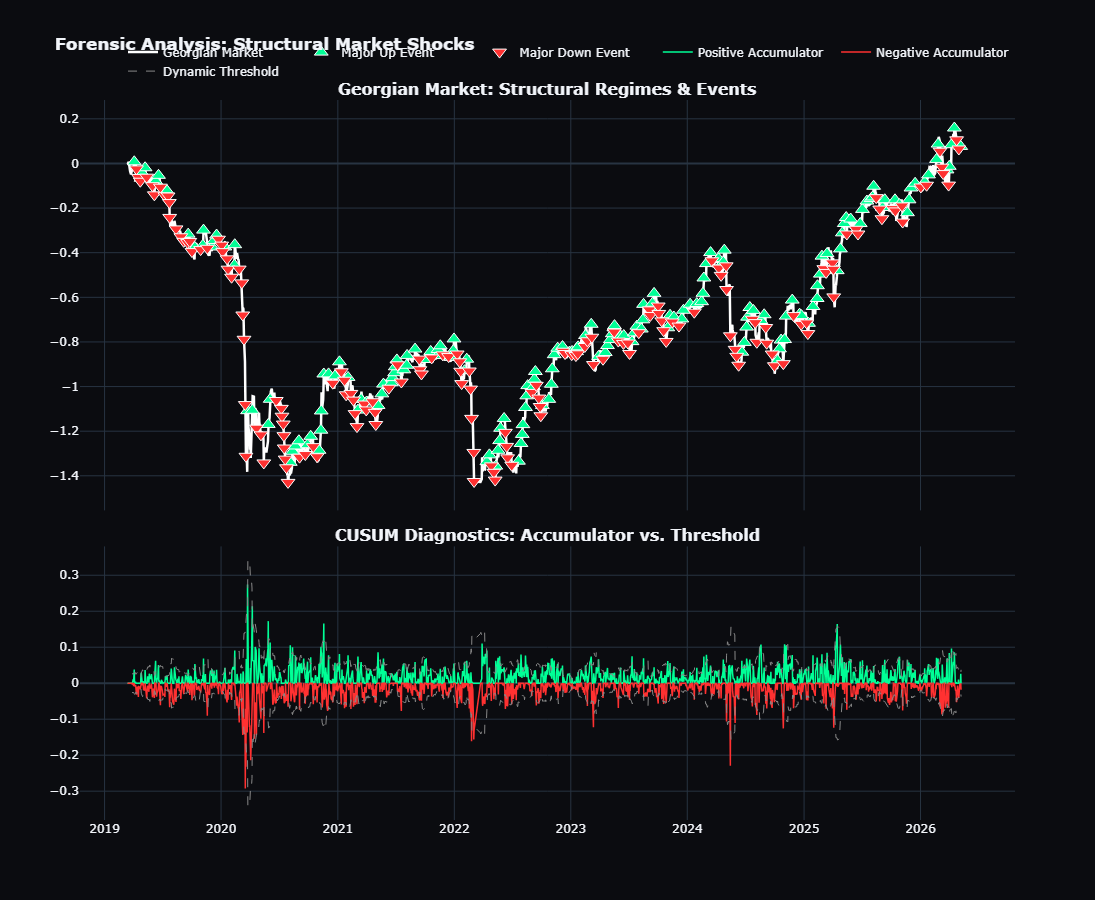

In [527]:
def plot_cusum_forensic_dashboard(equity_factor, cusum_path, X_events, factor_name_map):
    # 1. Data Preparation
    returns = _coerce_return_series(equity_factor)
    actual_cum = returns.cumsum()
    plot_df = cusum_path.copy()
    
    # Tooltip helper: Connects the event to the Macro factors
    def get_macro_string(date):
        if date not in X_events.index: return "No lead macro data"
        row = X_events.loc[date]
        top3 = row.abs().sort_values(ascending=False).head(3).index
        parts = []
        for col in top3:
            name = factor_name_map.get(col, col)
            val = row[col]
            emoji = "🟢" if val > 0 else "🔴"
            parts.append(f"{emoji} {name}: {val:.2f} SD")
        return "<br>".join(parts)

    # 2. Setup Figure
    fig = make_subplots(
        rows=2, cols=1, 
        shared_xaxes=True, 
        vertical_spacing=0.05,
        subplot_titles=("<b>Georgian Market: Structural Regimes & Events</b>", 
                        "<b>CUSUM Diagnostics: Accumulator vs. Threshold</b>"),
        row_heights=[0.6, 0.4]
    )

    # --- PANE 1: REGIME SHADING ---
    regimes = plot_df['event_side'].replace(0, np.nan).ffill().fillna(0)
    changes = regimes.diff().ne(0).cumsum()
    for reg_id in changes.unique():
        subset = regimes[changes == reg_id]
        val = subset.iloc[0]
        color = "rgba(0, 255, 150, 0.08)" if val == 1 else "rgba(255, 49, 49, 0.08)" if val == -1 else "rgba(0,0,0,0)"
        fig.add_vrect(x0=subset.index[0], x1=subset.index[-1], fillcolor=color, layer="below", line_width=0, row=1, col=1)

    # --- PANE 1: GEORGIAN MARKET ---
    fig.add_trace(go.Scatter(
        x=actual_cum.index, y=actual_cum, 
        name="Georgian Market",
        line=dict(color="#FFFFFF", width=2.5)
    ), row=1, col=1)

    # --- PANE 1: STRUCTURAL EVENTS ---
    up_events = plot_df[plot_df["event_side"] == 1]
    down_events = plot_df[plot_df["event_side"] == -1]

    if not up_events.empty:
        fig.add_trace(go.Scatter(
            x=up_events.index, y=actual_cum.loc[up_events.index],
            mode="markers", name="Major Up Event",
            marker=dict(color="#00FF96", size=12, symbol="triangle-up", line=dict(width=1, color="white")),
            customdata=[get_macro_string(d) for d in up_events.index],
            hovertemplate="<b>Major Up Event</b><br>%{customdata}<extra></extra>"
        ), row=1, col=1)

    if not down_events.empty:
        fig.add_trace(go.Scatter(
            x=down_events.index, y=actual_cum.loc[down_events.index],
            mode="markers", name="Major Down Event",
            marker=dict(color="#FF3131", size=12, symbol="triangle-down", line=dict(width=1, color="white")),
            customdata=[get_macro_string(d) for d in down_events.index],
            hovertemplate="<b>Major Down Event</b><br>%{customdata}<extra></extra>"
        ), row=1, col=1)

    # --- PANE 2: CUSUM ACCUMULATORS ---
    fig.add_trace(go.Scatter(x=plot_df.index, y=plot_df["positive_accumulator"], name="Positive Accumulator", line=dict(color="#00FF96", width=1.5)), row=2, col=1)
    fig.add_trace(go.Scatter(x=plot_df.index, y=plot_df["negative_accumulator"], name="Negative Accumulator", line=dict(color="#FF3131", width=1.5)), row=2, col=1)
    fig.add_trace(go.Scatter(x=plot_df.index, y=plot_df["positive_threshold"], name="Dynamic Threshold", line=dict(color="#888888", width=1, dash="dash")), row=2, col=1)
    fig.add_trace(go.Scatter(x=plot_df.index, y=plot_df["negative_threshold"], name="Dynamic Threshold", line=dict(color="#888888", width=1, dash="dash"), showlegend=False), row=2, col=1)

    # 3. Styling
    fig.update_layout(
        template="plotly_dark", height=900, width=1200,
        title_text="<b>Forensic Analysis: Structural Market Shocks</b>",
        hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        paper_bgcolor="#0b0c10", plot_bgcolor="#0b0c10"
    )
    return fig

fig = plot_cusum_forensic_dashboard(equity_factor, cusum_path, X_events, factor_name_map1)
fig.show()

### CUSUM dashboard export
Keeps the CUSUM chart data export used by the dashboard.


In [541]:
common_idx = cusum_path.index.intersection(equity_factor.index)

export_df = cusum_path.loc[common_idx].copy()
export_df = export_df.sort_index()
export_df = export_df[~export_df.index.duplicated(keep="last")]

# Cumulative Georgian market path, same as Python Plotly chart
export_df["Georgian_Market"] = equity_factor.loc[export_df.index].cumsum()

def get_macro_tooltip_text(date, X_events, factor_name_map):
    if date not in X_events.index:
        return "No lead macro data"

    row = X_events.loc[date]
    top3 = row.abs().sort_values(ascending=False).head(3).index

    return " | ".join([
        f"{factor_name_map.get(c, c)}: {row[c]:+.2f} SD"
        for c in top3
    ])

export_df["Macro_Context"] = [
    get_macro_tooltip_text(d, X_events, factor_name_map1)
    for d in export_df.index
]

# Make date a normal column, not hidden index
export_df = export_df.reset_index().rename(columns={"index": "Date"})

# Ensure date column name is exactly date
if "event_date" in export_df.columns and "Date" not in export_df.columns:
    export_df = export_df.rename(columns={"event_date": "Date"})

export_df["Date"] = pd.to_datetime(export_df["Date"]).dt.strftime("%Y-%m-%d")

export_df.to_csv("cusum_diagnostic_data_v2.csv", index=False)

print("Saved clean CUSUM CSV:", export_df.shape)
print(export_df[["Date", "Georgian_Market", "event_side", "Macro_Context"]].head())
print(export_df[["Date", "Georgian_Market", "event_side", "Macro_Context"]].tail())

Saved clean CUSUM CSV: (1840, 11)
         Date  Georgian_Market  event_side       Macro_Context
0  2019-03-14        -0.002885           0  No lead macro data
1  2019-03-15         0.002525           0  No lead macro data
2  2019-03-18         0.007255           0  No lead macro data
3  2019-03-19        -0.004677           0  No lead macro data
4  2019-03-20        -0.019541           0  No lead macro data
            Date  Georgian_Market  event_side  \
1835  2026-05-04         0.064035           0   
1836  2026-05-05         0.052895           0   
1837  2026-05-06         0.050139           0   
1838  2026-05-07         0.076405           1   
1839  2026-05-08         0.058341           0   

                                          Macro_Context  
1835                                 No lead macro data  
1836                                 No lead macro data  
1837                                 No lead macro data  
1838  Crypto volumes: +1.84 SD | Commodities: -1.80 ...  
183

## Stress simulation
Historical sensitivity check using the attribution model. This is not a forecast.


In [485]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def summarize_lasso_block_sensitivities(attrib, block_prefixes):
    """
    Summarizes Lasso sensitivity by factor block.

    Important:
    With StandardScaler on X only, Lasso coefficients represent
    target-return impact from a 1 standard deviation move in the feature.
    """
    pipeline = attrib["model"]
    lasso = pipeline.named_steps["model"]

    feature_names = pd.Index(pipeline.feature_names_in_)
    coefs = pd.Series(lasso.coef_, index=feature_names, name="lasso_coef")

    rows = []

    for block_name, prefix in block_prefixes.items():
        block_coefs = coefs[coefs.index.str.startswith(prefix)]

        rows.append({
            "block": block_name,
            "prefix": prefix,
            "n_features": len(block_coefs),
            "sensitivity_per_1sd": block_coefs.sum(),
            "abs_sensitivity": block_coefs.abs().sum(),
            "positive_coef_sum": block_coefs[block_coefs > 0].sum(),
            "negative_coef_sum": block_coefs[block_coefs < 0].sum(),
        })

    out = pd.DataFrame(rows)
    out["importance_share"] = out["abs_sensitivity"] / out["abs_sensitivity"].sum()

    return out.sort_values("abs_sensitivity", ascending=False)

In [487]:
block_prefixes = {
    "Global equities": "GLOBAL_EQUITY_RISK",
    "US Treasury rates": "GLOBAL_RATES",
    "Regional equities": "REGIONAL_EQUITY",
}

sensitivity_table = summarize_lasso_block_sensitivities(
    attrib=attrib,
    block_prefixes=block_prefixes
)

sensitivity_table

,block,prefix,n_features,sensitivity_per_1sd,abs_sensitivity,positive_coef_sum,negative_coef_sum,importance_share
0,Global equities,GLOBAL_EQUITY_RISK,2,0.015655,0.015655,0.015655,0.0,0.628579
2,Regional equities,REGIONAL_EQUITY,3,0.006558,0.006558,0.006558,0.0,0.263326
1,US Treasury rates,GLOBAL_RATES,2,0.002692,0.002692,0.002692,0.0,0.108095


In [513]:
def simulate_georgian_stress_test(
    attrib,
    cusum_path,
    global_eq_sd=0.0,
    rates_sd=0.0,
    regional_eq_sd=0.0,
    date=None,
    threshold_multiplier_label=None,
):
    """
    Simulates a macro shock using Lasso sensitivities and checks whether
    it would trigger a CUSUM event from the current accumulator state.

    Shock inputs are in standard deviation units:
        global_eq_sd = -2.0 means global equities factor falls by 2 SD.
        rates_sd = +1.0 means US rates factor rises by 1 SD.
        regional_eq_sd = -1.5 means regional equities factor falls by 1.5 SD.
    """

    pipeline = attrib["model"]
    lasso = pipeline.named_steps["model"]
    feature_names = pd.Index(pipeline.feature_names_in_)
    coefs = pd.Series(lasso.coef_, index=feature_names)

    def block_sensitivity(prefix):
        mask = coefs.index.str.startswith(prefix)
        return coefs.loc[mask].sum()

    # Sensitivity in target-return units per 1 SD block shock
    sensitivities = {
        "Global equities": block_sensitivity("GLOBAL_EQUITY_RISK"),
        "US Treasury rates": block_sensitivity("GLOBAL_RATES"),
        "Regional equities": block_sensitivity("REGIONAL_EQUITY"),
    }

    shocks = {
        "Global equities": global_eq_sd,
        "US Treasury rates": rates_sd,
        "Regional equities": regional_eq_sd,
    }

    contributions = {
        name: shocks[name] * sensitivities[name]
        for name in shocks
    }

    total_impact = sum(contributions.values())

    # Pick current CUSUM state
    cp = cusum_path.copy().sort_index()

    if date is None:
        current = cp.dropna(subset=[
            "positive_accumulator",
            "negative_accumulator",
            "positive_threshold",
            "negative_threshold",
        ]).iloc[-1]
        current_date = cp.dropna(subset=[
            "positive_accumulator",
            "negative_accumulator",
            "positive_threshold",
            "negative_threshold",
        ]).index[-1]
    else:
        date = pd.Timestamp(date)
        current = cp.loc[:date].dropna(subset=[
            "positive_accumulator",
            "negative_accumulator",
            "positive_threshold",
            "negative_threshold",
        ]).iloc[-1]
        current_date = cp.loc[:date].dropna(subset=[
            "positive_accumulator",
            "negative_accumulator",
            "positive_threshold",
            "negative_threshold",
        ]).index[-1]

    pos_acc = current["positive_accumulator"]
    neg_acc = current["negative_accumulator"]

    pos_threshold = current["positive_threshold"]
    neg_threshold = current["negative_threshold"]

    # One-step CUSUM simulation
    simulated_positive_accumulator = max(0, pos_acc + total_impact)
    simulated_negative_accumulator = min(0, neg_acc + total_impact)

    would_trigger_up = simulated_positive_accumulator > pos_threshold
    would_trigger_down = simulated_negative_accumulator < neg_threshold

    if would_trigger_up:
        event_text = "Potential major up CUSUM event"
        event_color = "#00CC96"
    elif would_trigger_down:
        event_text = "Potential major down CUSUM event"
        event_color = "#EF553B"
    else:
        event_text = "No CUSUM event triggered"
        event_color = "#A0AEC0"

    result = {
        "date": current_date,
        "total_impact": total_impact,
        "contributions": contributions,
        "sensitivities": sensitivities,
        "shocks": shocks,
        "current_positive_accumulator": pos_acc,
        "current_negative_accumulator": neg_acc,
        "simulated_positive_accumulator": simulated_positive_accumulator,
        "simulated_negative_accumulator": simulated_negative_accumulator,
        "positive_threshold": pos_threshold,
        "negative_threshold": neg_threshold,
        "would_trigger_up": would_trigger_up,
        "would_trigger_down": would_trigger_down,
        "event_text": event_text,
    }

    # Contribution table
    contrib_df = pd.DataFrame({
        "factor": list(contributions.keys()),
        "shock_sd": [shocks[k] for k in contributions.keys()],
        "sensitivity": [sensitivities[k] for k in contributions.keys()],
        "impact": [contributions[k] for k in contributions.keys()],
    })

    contrib_df["abs_impact"] = contrib_df["impact"].abs()
    contrib_df["impact_share"] = (
        contrib_df["abs_impact"] / contrib_df["abs_impact"].sum()
        if contrib_df["abs_impact"].sum() != 0
        else np.nan
    )

    # Plot
    fig = make_subplots(
        rows=1,
        cols=2,
        column_widths=[0.38, 0.62],
        specs=[[{"type": "indicator"}, {"type": "bar"}]],
        subplot_titles=(
            None,
            "<b>Contribution to simulated move</b>"
        )
    )

    fig.add_trace(go.Indicator(
        mode="number+delta",
        value=total_impact,
        title={
            "text": (
                "Implied Daily Move"
                f"<br><span style='color:{event_color};font-size:12px'>{event_text}</span>"
                f"<br><span style='color:gray;font-size:11px'>CUSUM state as of {current_date.date()}</span>"
            )
        },
        number={"valueformat": ".2%"},
        delta={"reference": 0, "relative": False}
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=contrib_df["impact"],
        y=contrib_df["factor"],
        orientation="h",
        marker_color=[
            "#00CC96" if x >= 0 else "#EF553B"
            for x in contrib_df["impact"]
        ],
        text=contrib_df["impact"].map(lambda x: f"{x:+.2%}"),
        textposition="outside",
        customdata=np.stack([
            contrib_df["shock_sd"],
            contrib_df["sensitivity"],
            contrib_df["impact_share"],
        ], axis=-1),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Shock: %{customdata[0]:+.2f} SD<br>"
            "Sensitivity: %{customdata[1]:+.4f}<br>"
            "Impact: %{x:+.2%}<br>"
            "Share of absolute impact: %{customdata[2]:.1%}"
            "<extra></extra>"
        )
    ), row=1, col=2)

    limit = max(
        abs(contrib_df["impact"]).max() * 1.4,
        abs(total_impact) * 1.4,
        abs(pos_threshold) * 1.2,
        abs(neg_threshold) * 1.2,
        0.001
    )

    fig.update_xaxes(
        range=[-limit, limit],
        tickformat=".1%",
        row=1,
        col=2
    )

    fig.add_shape(
    type="line",
    x0=0,
    x1=0,
    y0=0,
    y1=1,
    xref="x",
    yref="y domain",
    line=dict(
        color="gray",
        dash="dash",
        width=1
    )
    )

    fig.update_layout(
        template="plotly_dark",
        height=420,
        width=1000,
        title="<b>Stress Simulation:</b>",
        paper_bgcolor="#0b0c10",
        plot_bgcolor="#0b0c10",
        margin=dict(t=80, b=50, l=130, r=80),
        showlegend=False,
    )

    return fig, result, contrib_df

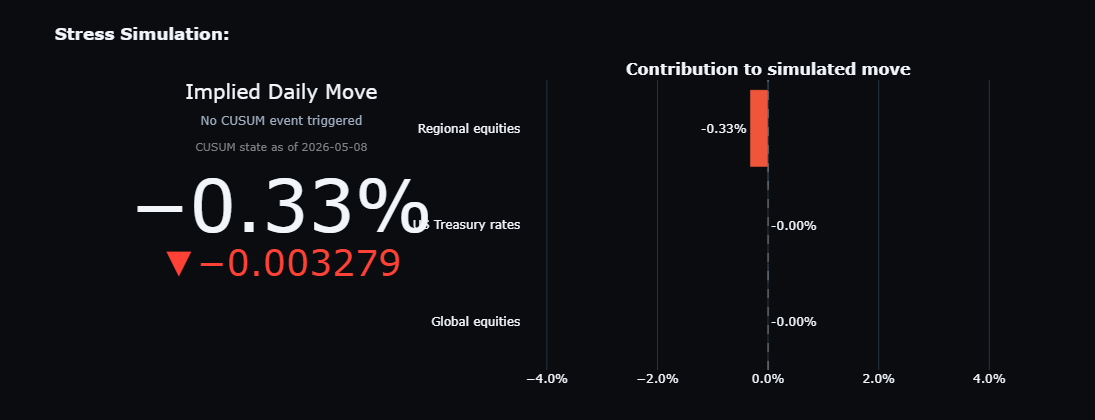

,factor,shock_sd,sensitivity,impact,abs_impact,impact_share
0,Global equities,-0.0,0.015655,-0.000000,0.000000,0.0
1,US Treasury rates,-0.0,0.002692,-0.000000,0.000000,0.0
2,Regional equities,-0.5,0.006558,-0.003279,0.003279,1.0


In [515]:
fig, result, contrib_df = simulate_georgian_stress_test(
    attrib=attrib,
    cusum_path=cusum_path,
    global_eq_sd=-0.0,     # global equities fall
    rates_sd=-0.0,         # rates rise
    regional_eq_sd=-0.5,   # regional equities fall
)

fig.show()
contrib_df

### Stress simulation export
Exports the stress simulation config JSON for the dashboard.


In [517]:
import json
from pathlib import Path
import numpy as np
import pandas as pd


def to_float(x):
    if pd.isna(x):
        return None
    return float(x)


def export_stress_simulation_config(
    attrib,
    cusum_path,
    output_path="stress_simulation_config.json"
):
    block_prefixes = {
        "Global equities": "GLOBAL_EQUITY_RISK",
        "US Treasury rates": "GLOBAL_RATES",
        "Regional equities": "REGIONAL_EQUITY",
    }

    sensitivity_table = summarize_lasso_block_sensitivities(
        attrib=attrib,
        block_prefixes=block_prefixes
    )

    # Latest usable CUSUM state
    cp = cusum_path.copy().sort_index()
    required_cols = [
        "positive_accumulator",
        "negative_accumulator",
        "positive_threshold",
        "negative_threshold",
    ]

    latest = cp.dropna(subset=required_cols).iloc[-1]
    latest_date = cp.dropna(subset=required_cols).index[-1]

    # Build factor list
    factors = []

    for _, row in sensitivity_table.iterrows():
        factors.append({
            "label": row["block"],
            "prefix": row["prefix"],
            "sensitivity_per_1sd": to_float(row["sensitivity_per_1sd"]),
            "abs_sensitivity": to_float(row["abs_sensitivity"]),
            "importance_share": to_float(row["importance_share"]),
            "positive_coef_sum": to_float(row["positive_coef_sum"]),
            "negative_coef_sum": to_float(row["negative_coef_sum"]),
        })

    config = {
        "title": "Stress Simulation",
        "subtitle": "Model-implied sensitivity to selected macro factor shocks",
        "model_note": (
            "Scenario impacts use Lasso sensitivities from the same-day diagnostic model. "
            "This is a historical sensitivity estimate, not a forecast or trading signal."
        ),
        "shock_unit": "standard deviations",
        "target_unit": "daily return",
        "factors": factors,
        "cusum_state": {
            "date": str(pd.Timestamp(latest_date).date()),
            "positive_accumulator": to_float(latest["positive_accumulator"]),
            "negative_accumulator": to_float(latest["negative_accumulator"]),
            "positive_threshold": to_float(latest["positive_threshold"]),
            "negative_threshold": to_float(latest["negative_threshold"]),
        },
        "default_shocks": {
            "Global equities": -1.0,
            "US Treasury rates": 0.0,
            "Regional equities": -0.5,
        },
        "slider": {
            "min": -3.0,
            "max": 3.0,
            "step": 0.25,
        },
        "important_interpretation_note": (
            "US Treasury rates refers to the PCA rates factor, not a raw yield change. "
            "A negative shock means the rates factor falls, which may not always mean raw yields fall. "
            "Interpret the sign through the model sensitivity and PCA construction."
        ),
    }

    Path(output_path).write_text(
        json.dumps(config, indent=2),
        encoding="utf-8"
    )

    print(f"Saved stress simulation config to: {output_path}")
    return config


stress_config = export_stress_simulation_config(
    attrib=attrib,
    cusum_path=cusum_path,
    output_path="stress_simulation_config.json"
)

Saved stress simulation config to: stress_simulation_config.json


## Next-day predictive model check
Ridge is used for the next-day predictive check. The weak result is part of the project conclusion.


In [367]:
def make_model_data(X, y, shift=1):
    """
    Creates aligned model data.

    shift=0:
        Same-day diagnostic model.
        X_t explains y_t.

    shift=1:
        Predictive model.
        X_{t-1} predicts y_t.
    """

    X_use = X.copy().sort_index()
    y_use = y.copy().sort_index()

    X_use = X_use.apply(pd.to_numeric, errors="coerce")
    y_use = pd.to_numeric(y_use, errors="coerce")

    if shift != 0:
        X_use = X_use.shift(shift)

    model_data = pd.concat(
        [y_use.rename("target"), X_use],
        axis=1
    ).dropna()

    y_clean = model_data["target"]
    X_clean = model_data.drop(columns=["target"])

    return X_clean, y_clean, model_data

In [369]:
def make_regression_models(n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)

    models = {
        "Mean Benchmark": None,

 #       "Linear Regression": Pipeline([
 #           ("scaler", StandardScaler()),
 #           ("model", LinearRegression())
 #       ]),

        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(
                alphas=np.logspace(-5, 5, 200),
                cv=tscv
            ))
        ]),

        "Lasso": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LassoCV(
                alphas=np.logspace(-6, 1, 200),
                cv=tscv,
                max_iter=100000,
                random_state=42
            ))
        ]),

        "Elastic Net": Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNetCV(
                alphas=np.logspace(-6, 1, 200),
                l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                cv=tscv,
                max_iter=100000,
                random_state=42
            ))
        ])
    }

    return models

In [370]:
def run_regression_experiment(
    X,
    y,
    split_date="2025-01-01",
    shift=1,
    n_splits=5
):
    X_clean, y_clean, model_data = make_model_data(
        X=X,
        y=y,
        shift=shift
    )

    split_date = pd.Timestamp(split_date)

    X_train = X_clean.loc[X_clean.index < split_date].copy()
    y_train = y_clean.loc[y_clean.index < split_date].copy()

    X_test = X_clean.loc[X_clean.index >= split_date].copy()
    y_test = y_clean.loc[y_clean.index >= split_date].copy()

    models = make_regression_models(n_splits=n_splits)

    results = []
    predictions = pd.DataFrame(index=y_test.index)
    predictions["actual"] = y_test

    fitted_models = {}

    for name, model in models.items():

        if name == "Mean Benchmark":
            y_pred = pd.Series(
                y_train.mean(),
                index=y_test.index,
                name=name
            )

        else:
            model.fit(X_train, y_train)
            fitted_models[name] = model

            y_pred = pd.Series(
                model.predict(X_test),
                index=y_test.index,
                name=name
            )

        predictions[name] = y_pred

        row = evaluate_predictions(y_test, y_pred, name)
        row["split_date"] = str(split_date.date())
        row["shift"] = shift
        row["train_start"] = X_train.index.min()
        row["train_end"] = X_train.index.max()
        row["test_start"] = X_test.index.min()
        row["test_end"] = X_test.index.max()
        row["n_train"] = len(X_train)
        row["n_test"] = len(X_test)

        results.append(row)

    results_df = pd.DataFrame(results).sort_values("r2", ascending=False)

    return {
        "results": results_df,
        "predictions": predictions,
        "fitted_models": fitted_models,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "model_data": model_data
    }

In [371]:
# Choose your final feature matrix and target here
X_predictive = X_selected_parsimonious.copy()
y_predictive = equity_factor.copy()

experiment_outputs = {}
all_results = []

for split_date in ["2025-01-01", "2026-01-01"]:
    for shift in [0, 1]:

        key = f"split_{split_date}_shift_{shift}"

        output = run_regression_experiment(
            X=X_predictive,
            y=y_predictive,
            split_date=split_date,
            shift=shift,
            n_splits=5
        )

        experiment_outputs[key] = output
        all_results.append(output["results"])

predictive_results_all = pd.concat(all_results, ignore_index=True)

predictive_results_all.sort_values(
    ["shift", "split_date", "r2"],
    ascending=[True, True, False]
)

,model,rmse,mae,r2,corr,direction_accuracy,split_date,shift,train_start,train_end,test_start,test_end,n_train,n_test
0,Lasso,0.018316,0.013683,0.367597,6.499168e-01,0.629310,2025-01-01,0,2019-03-14,2024-12-31,2025-01-02,2026-05-08,1492,348
1,Elastic Net,0.018316,0.013683,0.367597,6.499168e-01,0.629310,2025-01-01,0,2019-03-14,2024-12-31,2025-01-02,2026-05-08,1492,348
2,Ridge,0.018573,0.013875,0.349771,6.398624e-01,0.629310,2025-01-01,0,2019-03-14,2024-12-31,2025-01-02,2026-05-08,1492,348
3,Mean Benchmark,0.023176,0.016674,-0.012500,-3.462832e-18,0.471264,2025-01-01,0,2019-03-14,2024-12-31,2025-01-02,2026-05-08,1492,348
8,Lasso,0.017615,0.013422,0.450549,7.347308e-01,0.648352,2026-01-01,0,2019-03-14,2025-12-31,2026-01-02,2026-05-08,1749,91
9,Elastic Net,0.017647,0.013440,0.448529,7.335825e-01,0.659341,2026-01-01,0,2019-03-14,2025-12-31,2026-01-02,2026-05-08,1749,91
10,Ridge,0.018229,0.013803,0.411575,6.995436e-01,0.681319,2026-01-01,0,2019-03-14,2025-12-31,2026-01-02,2026-05-08,1749,91
11,Mean Benchmark,0.023824,0.017636,-0.005069,3.208685e-18,0.538462,2026-01-01,0,2019-03-14,2025-12-31,2026-01-02,2026-05-08,1749,91
4,Ridge,0.022844,0.016576,0.016288,2.361355e-01,0.505747,2025-01-01,1,2019-03-15,2024-12-31,2025-01-02,2026-05-08,1491,348
5,Elastic Net,0.022923,0.016570,0.009483,2.058751e-01,0.508621,2025-01-01,1,2019-03-15,2024-12-31,2025-01-02,2026-05-08,1491,348


In [372]:
dashboard_results = (
    predictive_results_all
    .query("model != 'Mean Benchmark'")
    .sort_values(["split_date", "shift", "r2"], ascending=[True, True, False])
    .groupby(["split_date", "shift"])
    .head(1)
    .reset_index(drop=True)
)

dashboard_results[
    [
        "split_date",
        "shift",
        "model",
        "r2",
        "corr",
        "direction_accuracy",
        "rmse",
        "mae",
        "n_train",
        "n_test"
    ]
]

,split_date,shift,model,r2,corr,direction_accuracy,rmse,mae,n_train,n_test
0,2025-01-01,0,Lasso,0.367597,0.649917,0.629310,0.018316,0.013683,1492,348
1,2025-01-01,1,Ridge,0.016288,0.236135,0.505747,0.022844,0.016576,1491,348
2,2026-01-01,0,Lasso,0.450549,0.734731,0.648352,0.017615,0.013422,1749,91
3,2026-01-01,1,Ridge,0.048404,0.328018,0.560440,0.023182,0.017420,1748,91


## Predictive performance visuals
Keeps the performance matrix and scatter views that compare diagnostic and predictive results.


In [373]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_performance_matrix(results_df):
    plot_df = results_df.copy()
    # Filter out benchmark
    plot_df = plot_df[plot_df["model"] != "Mean Benchmark"].copy()

    # Identify the best model for each setup (Split + Shift)
    best_df = (
        plot_df.sort_values("r2", ascending=False)
        .groupby(["split_date", "shift"])
        .head(1)
        .sort_values(["split_date", "shift"])
    )

    # Convert shift to a readable string for the legend
    best_df["Shift Type"] = best_df["shift"].map({0: "Diagnostic (t=0)", 1: "Predictive (t-1)"})
    
    # Define metrics to plot
    metrics = [
        ("r2", "R² (Variance Explained)", ".1%"),
        ("corr", "Pearson Correlation", ".2f"),
        ("direction_accuracy", "Directional Accuracy", ".1%")
    ]

    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=[m[1] for m in metrics],
        horizontal_spacing=0.08
    )

    # Custom colors for Diagnostic vs Predictive
    colors = {0: "#4C78A8", 1: "#E15759"} # Muted Blue vs Muted Red

    for i, (col_name, title, fmt) in enumerate(metrics, 1):
        for shift_val in [0, 1]:
            mask = best_df["shift"] == shift_val
            subset = best_df[mask]
            
            fig.add_trace(
                go.Bar(
                    x=subset["split_date"].astype(str),
                    y=subset[col_name],
                    name=subset["Shift Type"].iloc[0] if i == 1 else None,
                    marker_color=colors[shift_val],
                    text=subset[col_name].map(lambda x: f"{x:{fmt}}"),
                    textposition="outside",
                    # Add the best model name to hover
                    customdata=subset["model"],
                    hovertemplate="<b>%{x}</b><br>Model: %{customdata}<br>Value: %{y}<extra></extra>",
                    showlegend=(i == 1) # Only show legend once
                ),
                row=1, col=i
            )
        
        # Add a zero line for R2
        if col_name == "r2":
            fig.add_hline(y=0, line_color="#444", line_width=1, row=1, col=i)

    fig.update_layout(
        title="<b>Model Performance Matrix</b><br><sup>Comparison of Explainability (Shift 0) vs. Predictive Power (Shift 1) across different time splits</sup>",
        template="plotly_white",
        width=1200,
        height=550,
        barmode='group',
        legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="center", x=0.5),
        margin=dict(t=100, b=100, l=50, r=50)
    )

    # Axis formatting
    fig.update_yaxes(gridcolor="#EEEEEE", zeroline=False)
    fig.update_xaxes(title_text="Training Split Date")

    return fig

plot_performance_matrix(predictive_results_all).show()

In [374]:
import pandas as pd

# 1. Filter out benchmarks and find the best model for each (Date, Shift) combo
best_models = (
    predictive_results_all[predictive_results_all["model"] != "Mean Benchmark"]
    .sort_values("r2", ascending=False)
    .groupby(["split_date", "shift"])
    .head(1)
)

# 2. Pivot the data so Shift 0 and Shift 1 are in the same row
# This is required for side-by-side grouped bars in Recharts
perf_pivot = best_models.pivot(
    index="split_date", 
    columns="shift", 
    values=["r2", "corr", "direction_accuracy"]
)

# 3. Flatten column names: 'r2_shift_0', 'r2_shift_1', etc.
perf_pivot.columns = [f"{val}_shift_{col}" for val, col in perf_pivot.columns]
perf_pivot = perf_pivot.reset_index()

# 4. Save to CSV
perf_pivot.to_csv("model_performance_matrix.csv", index=False)
print("Exported: model_performance_matrix.csv")

Exported: model_performance_matrix.csv


In [375]:
import plotly.graph_objects as go
import numpy as np

def plot_interactive_split_scatter(experiment_outputs, model_name="Ridge", shift=1):
    # 1. Identify all available split dates from your experiment dictionary
    # Keys look like: 'split_2025-01-01_shift_1'
    keys = [k for k in experiment_outputs.keys() if f"shift_{shift}" in k]
    split_dates = sorted([k.split("_")[1] for k in keys])

    fig = go.Figure()

    # Store menu buttons
    buttons = []
    
    # We will create two traces (Hits and Misses) for EACH split date
    # Then we use the dropdown to toggle visibility
    for i, date in enumerate(split_dates):
        # Extract data for this split
        key = f"split_{date}_shift_{shift}"
        df = experiment_outputs[key]["predictions"].copy()
        df = df.rename(columns={model_name: "predicted"}).dropna()
        
        # Metrics
        acc = (np.sign(df["actual"]) == np.sign(df["predicted"])).mean()
        corr = df["actual"].corr(df["predicted"])
        
        # Split into Hits/Misses
        hit_mask = np.sign(df["actual"]) == np.sign(df["predicted"])
        
        # Calculate axis limits for this specific split
        x_lim = df["predicted"].abs().max() * 1.2
        y_lim = df["actual"].abs().max() * 1.1

        # Add Misses Trace
        fig.add_trace(go.Scatter(
            x=df.loc[~hit_mask, "predicted"], y=df.loc[~hit_mask, "actual"],
            mode="markers", name=f"Miss ({date})",
            marker=dict(color="#FF4B4B", size=8, opacity=0.4),
            visible=(i == 0), # Only first split visible by default
            hovertemplate="Actual: %{y:.4f}<br>Predicted: %{x:.4f}<extra></extra>"
        ))

        # Add Hits Trace
        fig.add_trace(go.Scatter(
            x=df.loc[hit_mask, "predicted"], y=df.loc[hit_mask, "actual"],
            mode="markers", name=f"Hit ({date})",
            marker=dict(color="#00FF96", size=9, opacity=0.8, line=dict(width=0.8, color="white")),
            visible=(i == 0),
            hovertemplate="Actual: %{y:.4f}<br>Predicted: %{x:.4f}<extra></extra>"
        ))

        # 2. Create the visibility mask for this button
        # Every split has 2 traces. We turn on only the two belonging to 'i'
        visibility = [False] * (len(split_dates) * 2)
        visibility[i*2] = True
        visibility[i*2 + 1] = True

        buttons.append(dict(
            label=f"Split: {date}",
            method="update",
            args=[
                {"visible": visibility},
                {
                    "title": f"<b>Predictive Quality: {date}</b><br><sup>Accuracy: {acc:.1%} | Correlation: {corr:.2f}</sup>",
                    "xaxis.range": [-x_lim, x_lim],
                    "yaxis.range": [-y_lim, y_lim]
                }
            ]
        ))

    # 3. Layout and Final Styling
    fig.update_layout(
        template="plotly_dark",
        updatemenus=[dict(
            type="dropdown", direction="down", x=0.01, y=1.15,
            showactive=True, active=0, buttons=buttons,
            bgcolor="#333", font=dict(color="white")
        )],
        xaxis_title="Model Explanation (Predicted Return)",
        yaxis_title="Georgian Market (Actual Return)",
        width=1000, height=800,
        showlegend=False,
        plot_bgcolor="#0F1115",
        paper_bgcolor="#0F1115",
        xaxis=dict(gridcolor="#222", zeroline=True, zerolinecolor="#444"),
        yaxis=dict(gridcolor="#222", zeroline=True, zerolinecolor="#444")
    )

    # Initialize the title for the first split
    first_key = f"split_{split_dates[0]}_shift_{shift}"
    first_df = experiment_outputs[first_key]["predictions"].rename(columns={model_name: "predicted"}).dropna()
    first_acc = (np.sign(first_df["actual"]) == np.sign(first_df["predicted"])).mean()
    first_corr = first_df["actual"].corr(first_df["predicted"])
    
    fig.update_layout(title=f"<b>Predictive Quality: {split_dates[0]}</b><br><sup>Accuracy: {first_acc:.1%} | Correlation: {first_corr:.2f}</sup>")

    return fig

# Execute
fig = plot_interactive_split_scatter(experiment_outputs)
fig.show()

In [376]:
import pandas as pd
import numpy as np

def export_multi_split_scatter(experiment_outputs, model_name="Ridge", shift=1):
    all_splits = []
    
    # 1. Loop through the experiment keys
    keys = [k for k in experiment_outputs.keys() if f"shift_{shift}" in k]
    
    for key in keys:
        split_date = key.split("_")[1]
        df = experiment_outputs[key]["predictions"].copy()
        
        # Rename model column to 'predicted'
        df = df.rename(columns={model_name: "predicted"}).dropna()
        
        # Add metadata columns for React
        df["split_date"] = split_date
        # Identify Hits (1) and Misses (0)
        df["is_hit"] = (np.sign(df["actual"]) == np.sign(df["predicted"])).astype(int)
        
        all_splits.append(df)
    
    # 2. Combine and save
    final_df = pd.concat(all_splits)
    final_df.index.name = "date"
    final_df.to_csv("predictive_scatter_all.csv")
    print(f"Exported {len(final_df)} points across {len(keys)} splits.")

# Execute
export_multi_split_scatter(experiment_outputs)

Exported 439 points across 2 splits.


## CUSUM-triggered prediction diagnostic
Explores whether CUSUM pressure changes how macro signals should be read.


In [377]:
def get_triggered_predictions(attrib, cusum_path, trigger_threshold=0.7):
    # 1. Align Data
    pred_daily = attrib["y_pred"]
    # Normalize pressure (how close are we to a breakout?)
    # We take the max of positive or negative pressure relative to the threshold
    up_pressure = cusum_path["positive_accumulator"] / cusum_path["positive_threshold"]
    down_pressure = abs(cusum_path["negative_accumulator"] / cusum_path["negative_threshold"])
    
    total_stress = pd.concat([up_pressure, down_pressure], axis=1).max(axis=1)
    
    # 2. Filter: Only keep Lasso prediction if Stress is high
    triggered_series = pred_daily.copy()
    triggered_series[total_stress < trigger_threshold] = np.nan
    
    # 3. Create DataFrame for dashboard
    df = pd.DataFrame({
        "actual": attrib["y_test"],
        "macro_signal": pred_daily,
        "stress_level": total_stress,
        "triggered_prediction": triggered_series
    }).dropna(subset=["actual"])
    
    # Identify "Valid Hits" (Both CUSUM and Lasso agree on direction)
    df["is_validated"] = (np.sign(df["actual"]) == np.sign(df["triggered_prediction"])).astype(float)
    df.loc[df["triggered_prediction"].isna(), "is_validated"] = np.nan
    
    return df

# Generate the data
triggered_df = get_triggered_predictions(attrib, cusum_path)

In [378]:
def plot_triggered_scatter(triggered_df):
    fig = go.Figure()

    # 1. Background Price Action (Faded)
    fig.add_trace(go.Scatter(
        x=triggered_df.index, y=triggered_df["actual"],
        mode="lines", name="Market Noise",
        line=dict(color="rgba(255,255,255,0.15)", width=1)
    ))

    # 2. Triggered Signals (Hits)
    hits = triggered_df[triggered_df["is_validated"] == 1]
    fig.add_trace(go.Scatter(
        x=hits.index, y=hits["actual"],
        mode="markers", name="Validated Macro Move",
        marker=dict(color="#00FF96", size=10, symbol="diamond", line=dict(width=1, color="white"))
    ))

    # 3. Triggered Signals (Misses/False Alarms)
    misses = triggered_df[triggered_df["is_validated"] == 0]
    fig.add_trace(go.Scatter(
        x=misses.index, y=misses["actual"],
        mode="markers", name="Idiosyncratic Move",
        marker=dict(color="#FF4B4B", size=8, opacity=0.6)
    ))

    fig.update_layout(
        template="plotly_dark",
        title="<b>CUSUM-Triggered Macro Signals</b><br><sup>Signals only fire when statistical pressure is high</sup>",
        xaxis_title="Date",
        yaxis_title="Daily Return",
        hovermode="x unified",
        plot_bgcolor="#0b0c10",
        paper_bgcolor="#0b0c10"
    )
    return fig

plot_triggered_scatter(triggered_df).show()

### Event diagnostics export
Exports event diagnostics for the dashboard.


In [379]:
# 1. Prepare the Event Diagnostics Data
# We use the 'standardized_difference' as the main value per your prompt
event_diagnostics_df = event_factor_comparison[['factor_name', 'standardized_difference', 't_stat']].copy()

# Filter out very low significance to keep the chart clean
event_diagnostics_df = event_diagnostics_df[event_diagnostics_df['t_stat'].abs() > 1.0]

# 2. Save to CSV
event_diagnostics_df.to_csv("event_diagnostics.csv", index=False)
print("Exported: event_diagnostics.csv")

Exported: event_diagnostics.csv


## Limitations and final notes
Diagnostic attribution works better than next-day prediction. CUSUM and stress simulation are monitoring tools, not trading signals or forecasts.
